# PMO presentation figures

Reproduces the exact population simulation and PMO calculation from
`ejima_hart_sim.ipynb` (same functions, same seed=2000) so every number here matches
the verified table in `slides_pmo_refined.md` §C, then builds the 8 figures slides 2-9
actually need: one real+illustrative comparison (slide 2), one new data figure (slide
4), two annotated single-panel re-exports of existing notebook plots (slides 5-6), and
four conceptual schematics with no underlying data (slides 1, 3, 7, 9).

Slide 8 (attribution) and slide 10 (close) need no matplotlib figure -- pure text/reuse,
per the figure plan in `slides_pmo_refined.md`.

Run with the `mcmc311` conda environment.

## Setup

In [1]:
import re

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import scienceplots
from scipy.integrate import solve_ivp

plt.style.use(["science", "notebook", "no-latex"])
mpl.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.top": False,
    "ytick.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.minor.visible": False,
    "ytick.minor.visible": True,
})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

In [2]:
OUT_DIR = "fig/pmo_presentation"
COL_UNVAX, COL_VAX = "tab:blue", "tab:orange"   # matches ejima_hart_sim.ipynb throughout


def save(fig, name):
    fig.savefig(f"{OUT_DIR}/{name}.svg", bbox_inches="tight", pad_inches=0.15)
    fig.savefig(f"{OUT_DIR}/{name}.png", dpi=200, bbox_inches="tight", pad_inches=0.15)
    print(f"saved {name}")

## Reproduce `ejima_hart_sim.ipynb`'s core computation

Same functions, same seed, so every number matches the verified table in `slides_pmo_refined.md`. Cell numbers in the headings below refer to the corresponding cells in `ejima_hart_sim.ipynb`.

### cell 4: NLME population estimates (Table 2, Ejima et al. 2025)

In [3]:
# --- cell 4: NLME population estimates (Table 2, Ejima et al. 2025) ---
GAMMA_POP, OMEGA_GAMMA = 4.25, 3.05
DELTA_POP, COV_VAX_DELTA, OMEGA_DELTA = 0.67, 0.95, 0.48
XI_POP, COV_AGE_XI, COV_VAX_XI, OMEGA_XI = 8.03e-7, -0.05, -1.81, 0.77
V0_POP, COV_VAX_V0, OMEGA_V0 = 8.98e7, 1.26, 2.29


def draw_params(n, vaccinated, age, rng=None):
    rng = rng or np.random.default_rng()
    v = 1.0 if vaccinated else 0.0
    gamma = GAMMA_POP * np.exp(rng.normal(0.0, OMEGA_GAMMA, n))
    delta = DELTA_POP * np.exp(COV_VAX_DELTA * v + rng.normal(0.0, OMEGA_DELTA, n))
    xi = XI_POP * np.exp(COV_AGE_XI * age + COV_VAX_XI * v + rng.normal(0.0, OMEGA_XI, n))
    V0 = V0_POP * np.exp(COV_VAX_V0 * v + rng.normal(0.0, OMEGA_V0, n))
    return gamma, delta, xi, V0

### cell 6: age + vaccination sampling

In [4]:
# --- cell 6: age + vaccination sampling ---
def load_sg_age_distribution(path):
    ages, counts = [], []
    in_total_block = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith("Singapore Residents,"):
                in_total_block = True
                continue
            if line.startswith("Singapore Male Residents,"):
                break
            if not in_total_block:
                continue
            m = re.match(r"^(\d+)\s+Year,(\d+)$", line)
            if m:
                ages.append(int(m.group(1)))
                counts.append(int(m.group(2)))
            m90 = re.match(r"^90 Years & Over,(\d+)$", line)
            if m90:
                ages.append(90)
                counts.append(int(m90.group(1)))
    ages, counts = np.array(ages), np.array(counts, dtype=float)
    return ages, counts / counts.sum()


SG_POP_PATH = "data/Singapore-population-2023.csv"
SG_AGES, SG_PROPORTIONS = load_sg_age_distribution(SG_POP_PATH)


def sample_population(n, seed):
    rng = np.random.default_rng(seed)
    age = rng.choice(SG_AGES, size=n, replace=True, p=SG_PROPORTIONS).astype(float)
    vac = rng.integers(0, 2, n).astype(float)
    return age, vac, rng

### cell 8: population construction (forward + backward ODE solve)

In [5]:
# --- cell 8: population construction (forward + backward ODE solve) ---
T_MAX_FULL = 80.0
T_FWD = np.arange(0.0, T_MAX_FULL + 1.0, 1.0)
T_BWD = np.arange(0.0, -T_MAX_FULL - 1.0, -1.0)
T_FULL = np.concatenate([T_BWD[::-1], T_FWD[1:]])
IDX0 = T_BWD.size - 1


def _rhs(t, y, xi, gamma, delta):
    f, V = y
    return [-xi * f * V, gamma * f * V - delta * V]


def solve_full(age, vac, rng):
    n = len(age)
    logV = np.full((n, T_BWD.size + T_FWD.size - 1), np.nan)
    for i in range(n):
        gamma, delta, xi, V0 = draw_params(1, bool(vac[i]), age=age[i], rng=rng)
        args = (xi[0], gamma[0], delta[0])
        sol_f = solve_ivp(_rhs, (0.0, T_MAX_FULL), [1.0, V0[0]], args=args,
                           method="LSODA", rtol=1e-8, atol=1e-10, dense_output=True)
        sol_b = solve_ivp(_rhs, (0.0, -T_MAX_FULL), [1.0, V0[0]], args=args,
                           method="LSODA", rtol=1e-8, atol=1e-10, dense_output=True)
        if sol_f.success and sol_b.success:
            Vf = sol_f.sol(T_FWD)[1]
            Vb = sol_b.sol(T_BWD)[1]
            logVf = np.log10(np.clip(Vf, 1e-12, None))
            logVb = np.log10(np.clip(Vb, 1e-12, None))
            logV[i] = np.concatenate([logVb[::-1][:-1], logVf])
    return logV


print("Solving 1000 patient trajectories (forward+backward, LSODA) -- matches "
      "ejima_hart_sim.ipynb cell 8 exactly, seed=2000 ...")
N_POP = 1000
age_pop, vac_pop, rng_pop = sample_population(N_POP, seed=2000)
logV_pop_full = solve_full(age_pop, vac_pop, rng_pop)
vac_mask = vac_pop.astype(bool)
n_ok = (~np.isnan(logV_pop_full).all(axis=1)).sum()
print(f"  {N_POP} patients ({int((~vac_mask).sum())} unvax / {int(vac_mask.sum())} vax), "
      f"{n_ok}/{N_POP} solves succeeded")

Solving 1000 patient trajectories (forward+backward, LSODA) -- matches ejima_hart_sim.ipynb cell 8 exactly, seed=2000 ...


  1000 patients (501 unvax / 499 vax), 1000/1000 solves succeeded


### cell 10: infectiousness + R0 calibration

In [6]:
# --- cell 10: infectiousness + R0 calibration ---
KAPPA, ALPHA_HILL, LAMBDA_HILL = 0.546, 0.8, 1e7


def beta_profile(logV):
    V = 10.0 ** logV
    return KAPPA * V ** ALPHA_HILL / (V ** ALPHA_HILL + LAMBDA_HILL ** ALPHA_HILL)


beta_pop = beta_profile(logV_pop_full)
B_pop = np.nansum(beta_pop, axis=1)
THETA_VAX_COHORT = 0.5
R0_ACTUAL = (THETA_VAX_COHORT * np.nanmean(B_pop[vac_mask])
             + (1 - THETA_VAX_COHORT) * np.nanmean(B_pop[~vac_mask]))
print(f"  R0_ACTUAL = {R0_ACTUAL:.4f}  (verified value: 3.1505)")

  R0_ACTUAL = 3.1505  (verified value: 3.1505)


### cell 12: per-patient R^(iso), R^(post)

In [7]:
# --- cell 12: per-patient R^(iso), R^(post) ---
Q_RANGE_FIX = np.arange(0, 31)


def B_iso_per_patient(beta_pop, Q_values):
    auc_backward = np.nansum(beta_pop[:, :IDX0], axis=1)
    out = np.empty((beta_pop.shape[0], len(Q_values)))
    for j, Q in enumerate(Q_values):
        out[:, j] = auc_backward + np.nansum(beta_pop[:, IDX0 + Q:], axis=1)
    return out


R_iso_pop = B_iso_per_patient(beta_pop, Q_RANGE_FIX)
R_v_i, R_u_i = R_iso_pop[vac_mask], R_iso_pop[~vac_mask]

### cell 14: fixed-point solvers

In [8]:
# --- cell 14: fixed-point solvers ---
def prob_any_transmission(R):
    return 1.0 - np.exp(-np.asarray(R, dtype=float))


def pdf_pmo_1d_sampled(R_v_i, R_u_i, theta_vax, n_iter=300, tol=1e-8):
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        g_v = np.nanmean(np.exp(-R_v_i * (1.0 - q)[None, :]), axis=0)
        g_u = np.nanmean(np.exp(-R_u_i * (1.0 - q)[None, :]), axis=0)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def pdf_pmo_2d_sampled(R_v_i, R_u_i, theta_vax, n_iter=300, tol=1e-8):
    n_Q = R_v_i.shape[1]
    q = np.zeros((n_Q, n_Q))
    for _ in range(n_iter):
        one_minus_q = 1.0 - q
        g_v = np.nanmean(np.exp(-R_v_i.T[None, :, :] * one_minus_q[:, :, None]), axis=2)
        g_u = np.nanmean(np.exp(-R_u_i.T[:, None, :] * one_minus_q[:, :, None]), axis=2)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def combined_min_days(grid, thresh, Q_grid):
    feas = grid < thresh
    if not feas.any():
        return None
    total_days = Q_grid[:, None] + Q_grid[None, :]
    min_total = np.where(feas, total_days, np.inf).min()
    tied = feas & (total_days == min_total)
    idx = np.unravel_index(np.argmin(np.where(tied, grid, np.inf)), grid.shape)
    return int(Q_grid[idx[0]]), int(Q_grid[idx[1]]), grid[idx]


def worst_subgroup_min_days(metric_u, metric_v, thresh, Q_grid):
    feas_u = metric_u < thresh
    feas_v = metric_v < thresh
    qu = int(Q_grid[feas_u].min()) if feas_u.any() else None
    qv = int(Q_grid[feas_v].min()) if feas_v.any() else None
    return qu, qv


pooled_pmo_curve = pdf_pmo_1d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT)
print(f"  pooled PMO(Q=0)={100*pooled_pmo_curve[0]:.2f}%  (Q=4)={100*pooled_pmo_curve[4]:.2f}%  "
      f"(verified: 84.25% / 28.13%)")

  pooled PMO(Q=0)=84.25%  (Q=4)=28.13%  (verified: 84.25% / 28.13%)


### cell 19: PMO_grid (used by slide 5)

In [9]:
# --- cell 19: PMO_grid (used by slide 5) ---
PMO_grid = pdf_pmo_2d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT)

### cell 28: average- vs worst-subgroup-constrained optimum

In [10]:
# --- cell 28: average- vs worst-subgroup-constrained optimum ---
PMO_u_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 0.0)
PMO_v_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 1.0)
avg_10 = combined_min_days(PMO_grid, 0.10, Q_RANGE_FIX)
worst_10 = worst_subgroup_min_days(PMO_u_only, PMO_v_only, 0.10, Q_RANGE_FIX)
print(f"  average-optimal PMO<10%: {avg_10}  worst-subgroup: {worst_10}  "
      f"(verified: (7,4,pooled 6.59%) / (8,3))")
qu_idx = list(Q_RANGE_FIX).index(avg_10[0])
qv_idx = list(Q_RANGE_FIX).index(avg_10[1])
print(f"  at (7,4): PMO_u_only={100*PMO_u_only[qu_idx]:.2f}%  (verified: 19.89%)")

  average-optimal PMO<10%: (7, 4, np.float64(0.06587685089839956))  worst-subgroup: (8, 3)  (verified: (7,4,pooled 6.59%) / (8,3))
  at (7,4): PMO_u_only=19.89%  (verified: 19.89%)


### cell 37: excess burden, Ct25 threshold

In [11]:
# --- cell 37: excess burden, Ct25 threshold ---
CT25_LOG10 = 6.11
logV_pop_fwd = logV_pop_full[:, IDX0:]
infectious = logV_pop_fwd >= CT25_LOG10
infectious_period = infectious.sum(axis=1)
ip_u, ip_v = infectious_period[~vac_mask], infectious_period[vac_mask]


def excess_burden(infectious_period_group, Q_values):
    return np.array([np.mean(np.maximum(Q - infectious_period_group, 0.0)) for Q in Q_values])


EX_u = excess_burden(ip_u, Q_RANGE_FIX)
EX_v = excess_burden(ip_v, Q_RANGE_FIX)

### cell 43: asymptomatic 6-type mixture

In [12]:
# --- cell 43: asymptomatic 6-type mixture ---
def pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, theta_vax, x_v, x_u, rho, phi=1.0, n_iter=300, tol=1e-8):
    Rv_full = R_v_i[:, :1]
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        omq = (1.0 - q)[None, :]
        g_v = np.nanmean((1 - x_v) * phi * np.exp(-R_v_i * omq)
                          + (1 - x_v) * (1 - phi) * np.exp(-Rv_full * omq)
                          + x_v * np.exp(-rho * Rv_full * omq), axis=0)
        g_u = np.nanmean((1 - x_u) * phi * np.exp(-R_u_i * omq)
                          + (1 - x_u) * (1 - phi) * np.exp(-Ru_full * omq)
                          + x_u * np.exp(-rho * Ru_full * omq), axis=0)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, theta_vax, x_v, x_u, rho, phi=1.0, n_iter=300, tol=1e-8):
    Rv_full = R_v_i[:, :1]
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros((n_Q, n_Q))
    for _ in range(n_iter):
        omq = (1.0 - q)[:, :, None]
        Rv_iso_b = R_v_i.T[None, :, :]
        Rv_full_b = Rv_full[:, 0][None, None, :]
        g_v = np.nanmean((1 - x_v) * phi * np.exp(-Rv_iso_b * omq)
                          + (1 - x_v) * (1 - phi) * np.exp(-Rv_full_b * omq)
                          + x_v * np.exp(-rho * Rv_full_b * omq), axis=2)
        Ru_iso_b = R_u_i.T[:, None, :]
        Ru_full_b = Ru_full[:, 0][None, None, :]
        g_u = np.nanmean((1 - x_u) * phi * np.exp(-Ru_iso_b * omq)
                          + (1 - x_u) * (1 - phi) * np.exp(-Ru_full_b * omq)
                          + x_u * np.exp(-rho * Ru_full_b * omq), axis=2)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


X_U_ILLUS, X_V_ILLUS = 0.20, 0.40

### cell 46: burden-vs-PMO divergence at the reference policy

In [13]:
# --- cell 46: burden-vs-PMO divergence at the reference policy ---
QU_REF, QV_REF, _ = combined_min_days(PMO_grid, 0.10, Q_RANGE_FIX)
PMO_grid_baseline_asymp = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, 0.0, 0.0, rho=1.0)
pmo_baseline_ref = PMO_grid_baseline_asymp[QU_REF, QV_REF]

X_U_SWEEP2 = np.array([0.0, 0.1, 0.2, 0.3, 0.4])
GAP2 = 0.20
ex_baseline_ref = THETA_VAX_COHORT * EX_v[QV_REF] + (1 - THETA_VAX_COHORT) * EX_u[QU_REF]
burden_ratios, pmo_pcts = [], []
for xu in X_U_SWEEP2:
    xv = xu + GAP2
    ex_ref = (THETA_VAX_COHORT * (1 - xv) * EX_v[QV_REF]
              + (1 - THETA_VAX_COHORT) * (1 - xu) * EX_u[QU_REF])
    burden_ratios.append(ex_ref / ex_baseline_ref)
    pmo_here = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, xv, xu, rho=1.0)[QU_REF, QV_REF]
    pmo_pcts.append(100 * pmo_here)
burden_ratios = np.array(burden_ratios)
pmo_pcts = np.array(pmo_pcts)
print(f"  reference policy (Qu,Qv)=({QU_REF},{QV_REF})  (verified: (7,4))")
print(f"  at x_u=0.20: burden={100*burden_ratios[2]:.1f}% of baseline  PMO={pmo_pcts[2]:.2f}%  "
      f"(verified: 73.1% / 35.27%)")

print("\nAll checks above should match the 'verified' values -- if not, stop and "
      "diagnose before trusting the figures below.\n")

  reference policy (Qu,Qv)=(7,4)  (verified: (7,4))
  at x_u=0.20: burden=73.1% of baseline  PMO=35.27%  (verified: 73.1% / 35.27%)

All checks above should match the 'verified' values -- if not, stop and diagnose before trusting the figures below.



## Slide 1 -- branching schematic (no data)

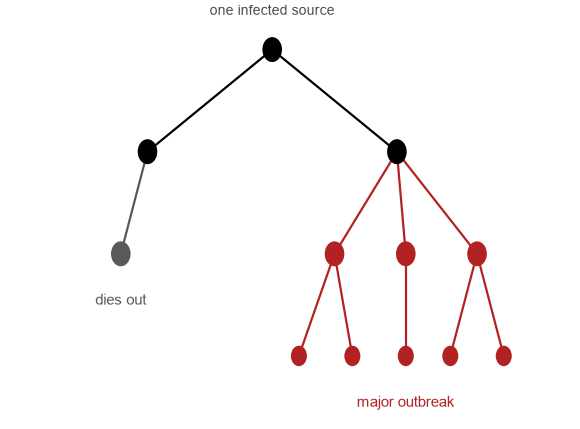

saved slide1_branching_schematic


In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_xlim(-3, 3.4)
ax.set_ylim(-0.3, 3.3)
ax.axis("off")


def node(x, y, r=0.11, color="black"):
    ax.add_patch(mpatches.Circle((x, y), r, facecolor=color, edgecolor="none", zorder=3))


def edge(p, q, color="black", lw=1.6, alpha=1.0):
    ax.plot([p[0], q[0]], [p[1], q[1]], color=color, lw=lw, alpha=alpha, zorder=2)


root = (0, 3)
node(*root)
left1, right1 = (-1.4, 2.1), (1.4, 2.1)
edge(root, left1)
edge(root, right1)
node(*left1)
node(*right1)

# left branch: one more generation, then stops (dies out)
left2 = (-1.7, 1.2)
edge(left1, left2, color="0.35")
node(*left2, color="0.35")
ax.text(left2[0], left2[1] - 0.35, "dies out", ha="center", va="top", fontsize=11, color="0.35")

# right branch: keeps branching (major outbreak)
r_children = [(0.7, 1.2), (1.5, 1.2), (2.3, 1.2)]
for c in r_children:
    edge(right1, c, color="firebrick")
    node(*c, color="firebrick")
r_grandchildren = [(0.3, 0.3), (0.9, 0.3), (1.5, 0.3), (2.0, 0.3), (2.6, 0.3)]
parents_cycle = [r_children[0], r_children[0], r_children[1], r_children[2], r_children[2]]
for p, c in zip(parents_cycle, r_grandchildren):
    edge(p, c, color="firebrick")
    node(*c, r=0.09, color="firebrick")
ax.text(1.5, -0.05, "major outbreak", ha="center", va="top", fontsize=11, color="firebrick")
ax.text(0, 3.28, "one infected source", ha="center", va="bottom", fontsize=10, color="0.3")
fig.tight_layout()
plt.show()
save(fig, "slide1_branching_schematic")
plt.close(fig)

## Slide 2 -- pooled PMO(Q) [real] vs illustrative LR(Q)

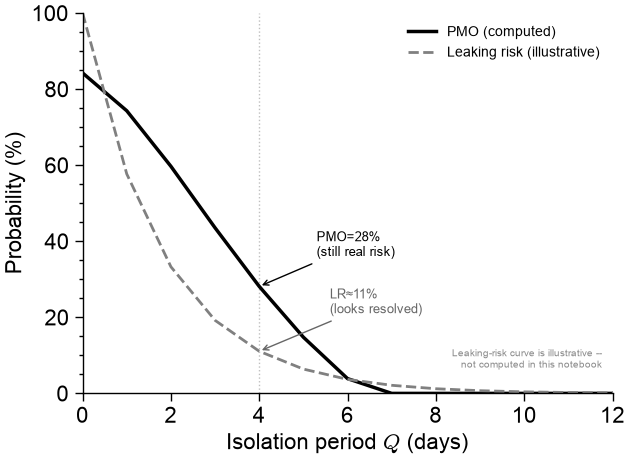

saved slide2_LR_vs_PMO


In [15]:
LR_illustrative = 100 * np.exp(-0.55 * Q_RANGE_FIX)   # illustrative only -- see notes

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(Q_RANGE_FIX, 100 * pooled_pmo_curve, color="black", lw=2.5, label="PMO (computed)")
ax.plot(Q_RANGE_FIX, LR_illustrative, color="0.5", lw=2, ls="--",
        label="Leaking risk (illustrative)")
ax.set_xlim(0, 12)
ax.set_ylim(0, 100)
ax.set_xlabel("Isolation period $Q$ (days)")
ax.set_ylabel("Probability (%)")
ax.legend(frameon=False, fontsize=10, loc="upper right")

# annotation at Q=4: real PMO vs illustrative LR
q_call = 4
pmo_call = 100 * pooled_pmo_curve[q_call]
lr_call = LR_illustrative[q_call]
ax.axvline(q_call, color="0.75", lw=1, ls=":", zorder=1)
ax.annotate(f"PMO={pmo_call:.0f}%\n(still real risk)", xy=(q_call, pmo_call),
            xytext=(q_call + 1.3, pmo_call + 8), fontsize=9.5, color="black",
            arrowprops=dict(arrowstyle="->", color="black", lw=1))
ax.annotate(f"LR≈{lr_call:.0f}%\n(looks resolved)", xy=(q_call, lr_call),
            xytext=(q_call + 1.6, lr_call + 10), fontsize=9.5, color="0.4",
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1))
ax.text(0.98, 0.06, "Leaking-risk curve is illustrative --\nnot computed in this notebook",
        transform=ax.transAxes, fontsize=7.5, color="0.55", ha="right", va="bottom")
fig.tight_layout()
plt.show()
save(fig, "slide2_LR_vs_PMO")
plt.close(fig)

## Slide 3 -- pipeline diagram (no data)

In [16]:
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 2)
ax.axis("off")

boxes = [
    ("Viral load\n$V_i(t)$", 1.1),
    ("Infectiousness\n$\\beta_i(t)$", 3.3),
    ("Transmission\npotential $B_i$", 5.5),
    ("Expected\noffspring $R_i$", 7.7),
    ("Outbreak\nprobability $p_{\\mathrm{out}}$", 9.9),
]
box_w, box_h = 1.7, 1.1
for label, cx in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((cx - box_w / 2, 1.0 - box_h / 2), box_w, box_h,
                                          boxstyle="round,pad=0.05,rounding_size=0.08",
                                          facecolor="#eef2f7", edgecolor="0.3", lw=1.2))
    ax.text(cx, 1.0, label, ha="center", va="center", fontsize=10.5)
for (_, cx1), (_, cx2) in zip(boxes[:-1], boxes[1:]):
    ax.annotate("", xy=(cx2 - box_w / 2 - 0.05, 1.0), xytext=(cx1 + box_w / 2 + 0.05, 1.0),
                arrowprops=dict(arrowstyle="-|>", color="0.25", lw=1.4))
fig.tight_layout()
save(fig, "slide3_pipeline_diagram")
plt.close(fig)

saved slide3_pipeline_diagram


## Slide 4 -- trajectory-fan plot (real data, new)

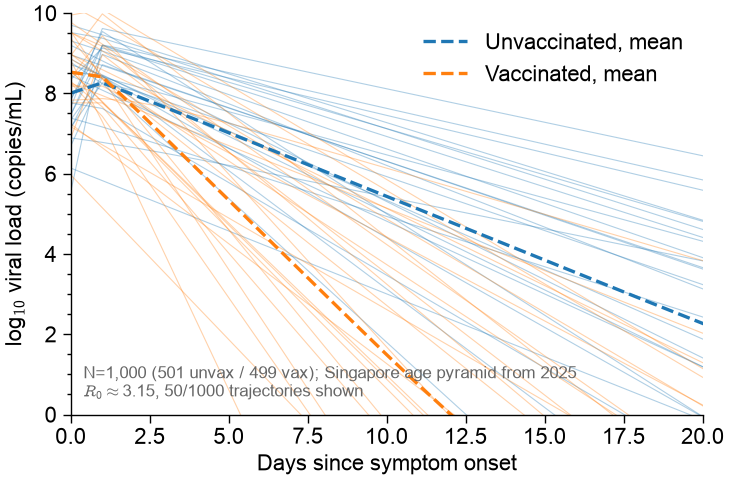

saved slide4_trajectory_fan


In [17]:
rng_sample = np.random.default_rng(7)
idx_unvax = rng_sample.choice(np.where(~vac_mask)[0], size=25, replace=False)
idx_vax = rng_sample.choice(np.where(vac_mask)[0], size=25, replace=False)

fig, ax = plt.subplots(figsize=(7.5, 5))
for i in idx_unvax:
    ax.plot(T_FWD, logV_pop_full[i, IDX0:], color=COL_UNVAX, lw=0.8, alpha=0.35)
for i in idx_vax:
    ax.plot(T_FWD, logV_pop_full[i, IDX0:], color=COL_VAX, lw=0.8, alpha=0.35)

mean_unvax = np.nanmean(logV_pop_full[~vac_mask, IDX0:], axis=0)
mean_vax = np.nanmean(logV_pop_full[vac_mask, IDX0:], axis=0)
ax.plot(T_FWD, mean_unvax, color=COL_UNVAX, lw=2.4, ls="--", label="Unvaccinated, mean")
ax.plot(T_FWD, mean_vax, color=COL_VAX, lw=2.4, ls="--", label="Vaccinated, mean")

ax.set_xlim(0, 20)
ax.set_ylim(0, 10)
ax.set_xlabel("Days since symptom onset")
ax.set_ylabel(r"log$_{10}$ viral load (copies/mL)")
ax.legend(frameon=False, loc="upper right")
ax.text(0.02, 0.03,
        f"N=1,000 ({int((~vac_mask).sum())} unvax / {int(vac_mask.sum())} vax); "
        f"Singapore age pyramid from 2025\n"
        rf"$R_0\approx${R0_ACTUAL:.2f}, 50/1000 trajectories shown",
        transform=ax.transAxes, fontsize=12, color="0.4", ha="left", va="bottom")
fig.tight_layout()
plt.show()
save(fig, "slide4_trajectory_fan")
plt.close(fig)

## Slide 5 -- annotated (Qu,Qv) plane, PMO only (cell 28, panel 6b), single panel

saved slide5_pooled_vs_subgroup


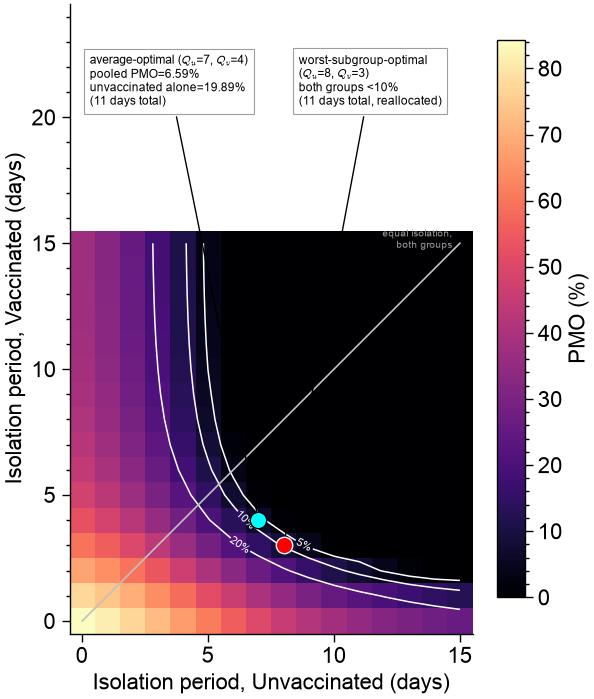

In [18]:
fig, ax = plt.subplots(figsize=(7, 7.2))
# Restrict to Q<=15 for both imshow and contour -- contour() otherwise draws over the
# FULL Q_RANGE_FIX (0-30) regardless of imshow's extent, which leaks stray contour
# lines into the annotation zone once ylim is extended above the heatmap below.
Q_PLOT = Q_RANGE_FIX[Q_RANGE_FIX <= 15]
PMO_PLOT = PMO_grid[:len(Q_PLOT), :len(Q_PLOT)]
im = ax.imshow(100 * PMO_PLOT.T, origin="lower",
                extent=[Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5,
                        Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5],
                aspect="equal", cmap="magma")
cs = ax.contour(Q_PLOT, Q_PLOT, 100 * PMO_PLOT.T, levels=[5, 10, 20],
                 colors="white", linewidths=1.1)
ax.clabel(cs, fmt="%d%%", fontsize=8)
ax.plot(Q_PLOT, Q_PLOT, color="silver", lw=1.2)
ax.text(14.7, 14.7, "equal isolation,\nboth groups", color="0.6", fontsize=7.5,
        ha="right", va="bottom", rotation=0)

qu_a, qv_a = avg_10[0], avg_10[1]
qu_w, qv_w = worst_10[0], worst_10[1]
ax.scatter(qu_a, qv_a, color="cyan", marker="o", s=140, edgecolors="black", linewidths=1.0, zorder=5)
ax.scatter(qu_w, qv_w, color="red", marker="o", s=140, edgecolors="white", linewidths=1.0, zorder=6)

# Annotation zone: extend ylim well above the heatmap (which only covers -0.5..15.5)
# so both callouts sit on plain white background, not on top of the grid/contours.
box_kw = dict(fc="white", ec="0.6", lw=0.8, alpha=0.95, pad=4)
ax.annotate(f"average-optimal ($Q_u$={qu_a}, $Q_v$={qv_a})\n"
            f"pooled PMO={100*avg_10[2]:.2f}%\n"
            f"unvaccinated alone={100*PMO_u_only[qu_idx]:.2f}%\n"
            f"(11 days total)",
            xy=(qu_a, qv_a), xycoords="data",
            xytext=(0.3, 20.5), textcoords="data", fontsize=8.5, ha="left",
            bbox=box_kw, arrowprops=dict(arrowstyle="->", color="black", lw=1))
ax.annotate(f"worst-subgroup-optimal\n($Q_u$={qu_w}, $Q_v$={qv_w})\n"
            f"both groups <10%\n"
            f"(11 days total, reallocated)",
            xy=(qu_w, qv_w), xycoords="data",
            xytext=(8.6, 20.5), textcoords="data", fontsize=8.5, ha="left",
            bbox=box_kw, arrowprops=dict(arrowstyle="->", color="black", lw=1))

ax.set_xlabel("Isolation period, Unvaccinated (days)")
ax.set_ylabel("Isolation period, Vaccinated (days)")
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(-0.5, 24.5)
fig.colorbar(im, ax=ax, label="PMO (%)", fraction=0.046, pad=0.04)
fig.tight_layout()
save(fig, "slide5_pooled_vs_subgroup")
plt.show()
plt.close(fig)

## Slide 6 -- annotated burden-vs-PMO divergence (cell 46, panel 12b), single panel

saved slide6_burden_pmo_divergence


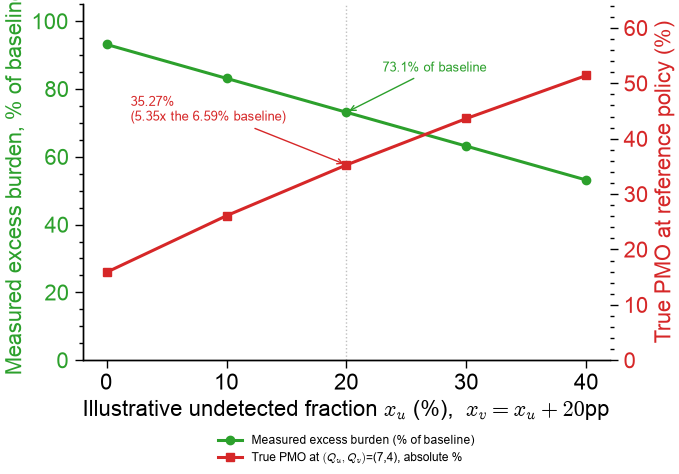

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
l1, = ax.plot(100 * X_U_SWEEP2, 100 * burden_ratios, color="tab:green", lw=2.2, marker="o", ms=6,
              label="Measured excess burden (% of baseline)")
ax.set_xlabel(r"Illustrative undetected fraction $x_u$ (%),  $x_v=x_u+20$pp")
ax.set_ylabel("Measured excess burden, % of baseline", color="tab:green")
ax.tick_params(axis="y", labelcolor="tab:green")
ax.set_ylim(0, 105)

ax2 = ax.twinx()
l2, = ax2.plot(100 * X_U_SWEEP2, pmo_pcts, color="tab:red", lw=2.2, marker="s", ms=6,
               label=rf"True PMO at $(Q_u,Q_v)$=({QU_REF},{QV_REF}), absolute %")
ax2.set_ylabel("True PMO at reference policy (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, max(pmo_pcts) * 1.25)
ax2.spines["top"].set_visible(False)

ax.axvline(20, color="0.75", lw=1, ls=":", zorder=1)
ax.annotate("73.1% of baseline", xy=(20, 100 * burden_ratios[2]),
            xytext=(23, 100 * burden_ratios[2] + 12), fontsize=9.5, color="tab:green",
            arrowprops=dict(arrowstyle="->", color="tab:green", lw=1))
ax2.annotate(f"{pmo_pcts[2]:.2f}%\n(5.35x the {100*pmo_baseline_ref:.2f}% baseline)",
             xy=(20, pmo_pcts[2]), xytext=(2, pmo_pcts[2] + 8), fontsize=9.5, color="tab:red",
             arrowprops=dict(arrowstyle="->", color="tab:red", lw=1))

ax.legend(handles=[l1, l2], frameon=False, fontsize=8.5, loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=1)
fig.tight_layout()
save(fig, "slide6_burden_pmo_divergence")
plt.show()
plt.close(fig)

## Slide 7 -- two-box mechanism schematic (no data)

saved slide7_mechanism_schematic


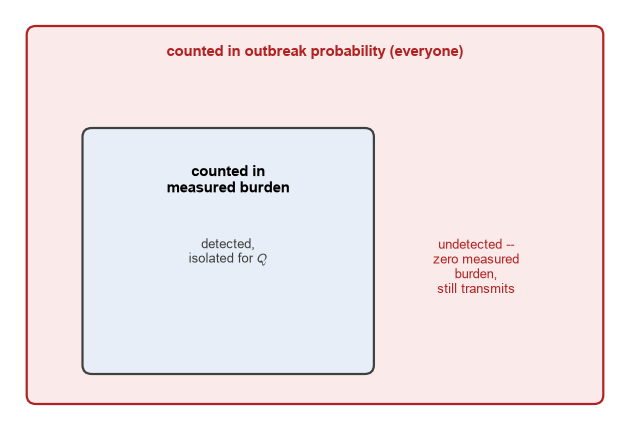

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis("off")

outer = mpatches.FancyBboxPatch((0.4, 0.4), 9.2, 6.2, boxstyle="round,pad=0.05,rounding_size=0.15",
                                 facecolor="#fbeaea", edgecolor="firebrick", lw=1.6)
ax.add_patch(outer)
ax.text(5, 6.15, "counted in outbreak probability (everyone)", ha="center", fontsize=11,
        color="firebrick", fontweight="bold")

inner = mpatches.FancyBboxPatch((1.3, 0.9), 4.6, 4.0, boxstyle="round,pad=0.05,rounding_size=0.15",
                                 facecolor="#e7eef7", edgecolor="0.25", lw=1.6)
ax.add_patch(inner)
ax.text(3.6, 4.35, "counted in\nmeasured burden", ha="center", va="top", fontsize=10.5, fontweight="bold")
ax.text(3.6, 2.7, "detected,\nisolated for $Q$", ha="center", fontsize=9.5, color="0.25")

ax.text(7.6, 2.2, "undetected --\nzero measured\nburden,\nstill transmits", ha="center",
        fontsize=9.5, color="firebrick")
fig.tight_layout()
save(fig, "slide7_mechanism_schematic")
plt.show()

plt.close(fig)

## Slide 9 -- current-vs-proposed workflow diagram (no data)

In [21]:
fig, ax = plt.subplots(figsize=(10.4, 3.4))
ax.set_xlim(0, 10.4)
ax.set_ylim(0, 3.4)
ax.axis("off")


def flow(y, boxes, color, label):
    ax.text(0.15, y + 0.55, label, fontsize=10.5, fontweight="bold", color=color)
    xs = np.linspace(1.4, 9.0, len(boxes))
    for x, text in zip(xs, boxes):
        ax.add_patch(mpatches.FancyBboxPatch((x - 0.9, y - 0.4), 1.8, 0.8,
                                              boxstyle="round,pad=0.04,rounding_size=0.08",
                                              facecolor="white", edgecolor=color, lw=1.4))
        ax.text(x, y, text, ha="center", va="center", fontsize=8.7)
    for x1, x2 in zip(xs[:-1], xs[1:]):
        ax.annotate("", xy=(x2 - 0.95, y), xytext=(x1 + 0.95, y),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3))


flow(2.4, ["Ejima\nfit", "simulated\npopulation", "PMO"], "0.35", "Current")
flow(0.9, ["detection-independent\nsurveillance", "detection /\nsymptom model", "PMO"],
     "tab:red", "Proposed")
fig.tight_layout()
save(fig, "slide9_workflow_diagram")
plt.close(fig)

print("\nDone. 8 figures written to", OUT_DIR)

saved slide9_workflow_diagram

Done. 8 figures written to fig/pmo_presentation


## Eq. 6.3 vs Eq. 6.4, same patient, one plot (Slide 4)

Same patient for both curves -- the point is that *both* numbers come from one simulated trajectory, once you have $R_i(Q)$. Left axis (orange): Eq. 6.3, $1-\exp(-R_i^{(\mathrm{iso})}(Q))$ -- *does this person infect anyone at all*. Right axis (dark blue): Eq. 6.4, $1-\exp(-R_i^{(\mathrm{post})}(Q)\,p_{\mathrm{out}})$ -- *does a post-release infection from this person go on to seed a major outbreak*.

Patient choice: not the median patient (that one had $R(0)\approx3.2$, deep in the saturated part of $1-e^{-x}$, where the two curves nearly coincide). Instead, picking whoever in the full 1,000-patient population has $R_i(Q{=}0)$ closest to $R^*=\frac{-\ln p_{\mathrm{out}}}{1-p_{\mathrm{out}}}\approx1.09$ -- the value that *maximises* $e^{-R^*p_{\mathrm{out}}}-e^{-R^*}$, i.e. the largest possible gap between the two curves. That value sits almost exactly at the branching-process critical threshold $R=1$, so this isn't a cherry-picked outlier -- it's the patient for whom 'transmits' and 'seeds an outbreak' are structurally as distinguishable as this population ever makes them.

p_out_ambient=0.8425  R*=1.088 (max-gap R, vs. critical R=1)
patient #530 (vaccinated): R_i(Q=0)=1.090
Eq 6.3 at Q=0: P=66.4%   Eq 6.4 at Q=0: P=60.1%
max gap = 6.3pp at Q=0


saved one_individual_eq63_vs_eq64


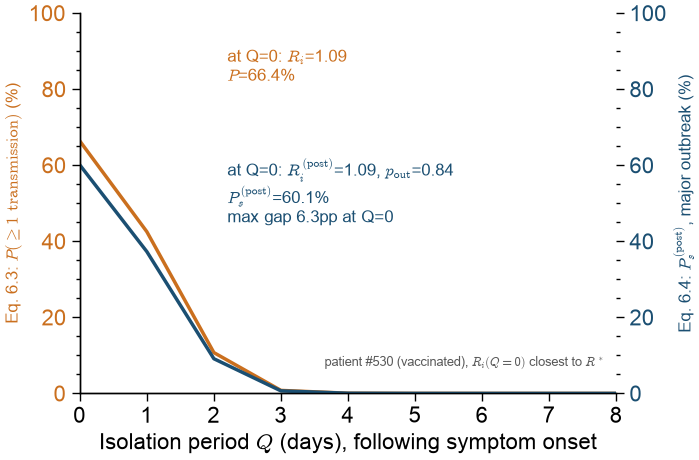

In [22]:
COL_V, COL_BETA = "#1b4f72", "#ca6f1e"

# ambient p_out: population-level outbreak probability with NO isolation (Q=0), pooled
p_out_ambient = pdf_pmo_1d_sampled(R_v_i[:, :1], R_u_i[:, :1], THETA_VAX_COHORT)[0]

# R* maximising the gap between Eq 6.3 and Eq 6.4 curves: e^{-R*p_out} - e^{-R}
R_star = -np.log(p_out_ambient) / (1 - p_out_ambient)
print(f"p_out_ambient={p_out_ambient:.4f}  R*={R_star:.3f} (max-gap R, vs. critical R=1)")

# patient (either vax status) whose R_i(Q=0) is closest to R*
idx_pick = np.argmin(np.abs(R_iso_pop[:, 0] - R_star))
is_vax = bool(vac_mask[idx_pick])
group_label = "vaccinated" if is_vax else "unvaccinated"
COL_PATIENT = COL_VAX if is_vax else COL_UNVAX

R_one = R_iso_pop[idx_pick]                                # Eq. 6.3's R_i^(iso)(Q)
P_one = prob_any_transmission(R_one)                        # Eq. 6.3

def B_post_per_patient(beta_pop, Q_values):
    out = np.empty((beta_pop.shape[0], len(Q_values)))
    for j, Q in enumerate(Q_values):
        out[:, j] = np.nansum(beta_pop[:, IDX0 + Q:], axis=1)
    return out

R_post_pop = B_post_per_patient(beta_pop, Q_RANGE_FIX)
R_post_one = R_post_pop[idx_pick]                           # Eq. 6.4's R_i^(post)(Q)
P_one_post = 1.0 - np.exp(-R_post_one * p_out_ambient)       # Eq. 6.4

max_gap = 100 * np.max(P_one - P_one_post)
q_at_max_gap = Q_RANGE_FIX[np.argmax(P_one - P_one_post)]
print(f"patient #{idx_pick} ({group_label}): R_i(Q=0)={R_one[0]:.3f}")
print(f"Eq 6.3 at Q=0: P={100*P_one[0]:.1f}%   Eq 6.4 at Q=0: P={100*P_one_post[0]:.1f}%")
print(f"max gap = {max_gap:.1f}pp at Q={q_at_max_gap}")

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(Q_RANGE_FIX, 100 * P_one, color=COL_BETA, lw=2.5)
ax.set_xlabel("Isolation period $Q$ (days), following symptom onset")
ax.set_ylabel(r"Eq. 6.3: $P(\geq 1\ \mathrm{transmission})$ (%)", color=COL_BETA, fontsize=12)
ax.tick_params(axis="y", labelcolor=COL_BETA)
Q_PLOT_MAX = 8
ax.set_xlim(0, Q_PLOT_MAX)
ax.set_ylim(0, 100)
ax.text(2.2, 82, rf"at Q=0: $R_i$={R_one[0]:.2f}" "\n" rf"$P$={100*P_one[0]:.1f}%",
        fontsize=12, color=COL_BETA)

ax2 = ax.twinx()
ax2.plot(Q_RANGE_FIX, 100 * P_one_post, color=COL_V, lw=2.5)
ax2.set_ylabel(r"Eq. 6.4: $P_s^{(\mathrm{post})}$, major outbreak (%)", color=COL_V, fontsize=12)
ax2.tick_params(axis="y", labelcolor=COL_V)
ax2.set_ylim(0, 100)
ax2.spines["top"].set_visible(False)
ax2.text(2.2, 45, rf"at Q=0: $R_i^{{(\mathrm{{post}})}}$={R_post_one[0]:.2f}, $p_{{\mathrm{{out}}}}$={p_out_ambient:.2f}"
         "\n" rf"$P_s^{{(\mathrm{{post}})}}$={100*P_one_post[0]:.1f}%"
         "\n" f"max gap {max_gap:.1f}pp at Q={q_at_max_gap}",
         fontsize=12, color=COL_V)

ax.text(0.98, 0.06, f"patient #{idx_pick} ({group_label}), $R_i(Q{{=}}0)$ closest to $R^*$",
        transform=ax.transAxes, fontsize=9, color="0.35", ha="right", va="bottom")

fig.tight_layout()
save(fig, "one_individual_eq63_vs_eq64")
plt.show()
plt.close(fig)

## Plot 2 -- independently swept $(Q_{\mathrm{unvax}}, Q_{\mathrm{vax}})$

From `ejima_hart_sim.ipynb`. Same population-sampled pools (`R_v_i`, `R_u_i`) as the slides above, now with the two groups' isolation periods swept **independently** rather than pooled into one $Q$.

**2a** -- population-averaged $P(\geq1\text{ transmission})$ (Eq. 6.3, averaged per group, no branching-process consequence):
$$\bar P(\geq1\text{ transmission}) = \theta\,\mathrm{mean}_i\big[1-e^{-R_{v,i}(Q_v)}\big] + (1-\theta)\,\mathrm{mean}_i\big[1-e^{-R_{u,i}(Q_u)}\big]$$

**2b** -- PMO, the joint fixed point (Eq. 7.1, independent $(Q_u,Q_v)$ axes, `pdf_pmo_2d_sampled`):
$$q = \theta\,\mathrm{mean}_i\big[e^{-R_{v,i}(Q_v)(1-q)}\big] + (1-\theta)\,\mathrm{mean}_i\big[e^{-R_{u,i}(Q_u)(1-q)}\big], \qquad \mathrm{PMO}=1-q$$

This is a *self-consistent* fixed point: offspring isolate under this same $(Q_u,Q_v)$ too, at every generation -- so PMO collapses to 0 once population-wide $\mathcal R_{\mathrm{eff}}<1$, the branching-process criticality cliff. Markers: `combined_min_days` finds the minimum *total* isolation-days $(Q_u+Q_v)$ satisfying each risk threshold.

saved plot2_transmission_and_pmo_grids


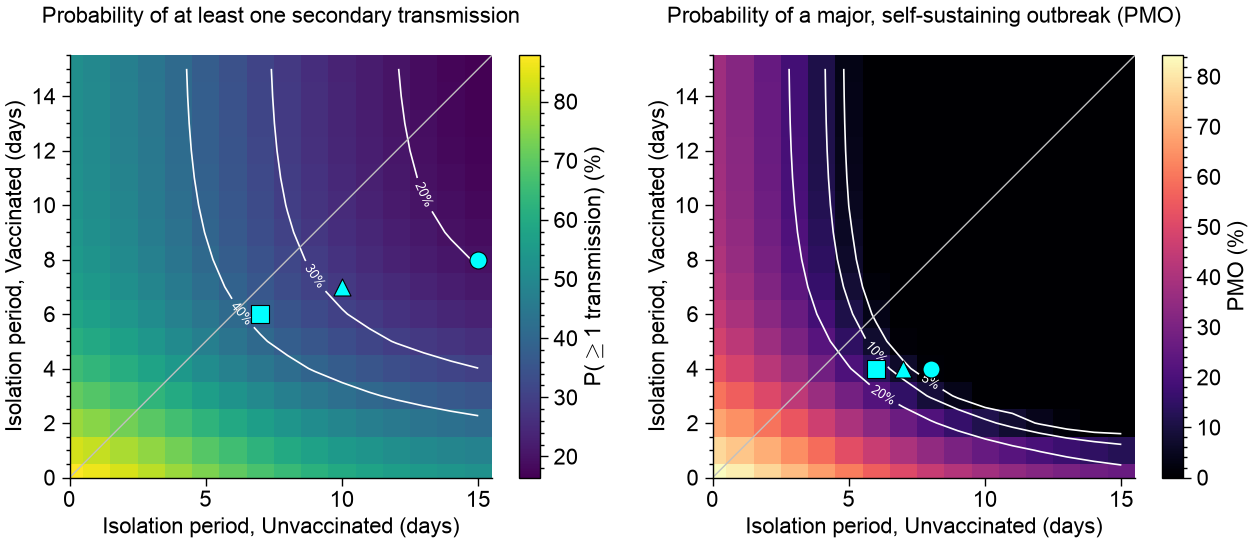

In [23]:
MARKERS_2 = ["o", "^", "s"]

PROB_TRANSMIT_grid = (THETA_VAX_COHORT * np.nanmean(prob_any_transmission(R_v_i), axis=0)[None, :]
                       + (1 - THETA_VAX_COHORT) * np.nanmean(prob_any_transmission(R_u_i), axis=0)[:, None])
# PMO_grid already computed above (cell 19: pdf_pmo_2d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, grid, cmap, title, cbar_label, letter, levels in [
    (axes[0], PROB_TRANSMIT_grid, "viridis", "Probability of at least one secondary transmission",
     r"P($\geq$1 transmission) (%)", "2a", [20, 30, 40]),
    (axes[1], PMO_grid, "magma", "Probability of a major, self-sustaining outbreak (PMO)",
     "PMO (%)", "2b", [5, 10, 20]),
]:
    # contour + clabel restricted to the visible Q<=15 window -- computing them over
    # the full Q_RANGE_FIX (0-30) places clabel's auto label positions beyond the
    # visible xlim, so labels silently fall outside the plotted area (same fix as
    # the Slide 5 heatmap above).
    Q_PLOT = Q_RANGE_FIX[Q_RANGE_FIX <= 15]
    grid_plot = grid[:len(Q_PLOT), :len(Q_PLOT)]
    im = ax.imshow(100 * grid_plot.T, origin="lower",
                    extent=[Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5,
                            Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5],
                    aspect="equal", cmap=cmap)
    cs = ax.contour(Q_PLOT, Q_PLOT, 100 * grid_plot.T, levels=levels, colors="white", linewidths=1.2)
    ax.clabel(cs, fmt="%d%%", fontsize=9, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, ls="-", label="fixed isolation period")

    for level, marker in zip(levels, MARKERS_2):
        result = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv, val = result
            ax.scatter(qu, qv, color="cyan", marker=marker, s=150, edgecolors="black", linewidths=0.8,
                       zorder=5, label=rf"min days, <{level}% ($Q_u$={qu}, $Q_v$={qv}, total={qu + qv}d)")

    ax.set_xlabel("Isolation period, Unvaccinated (days)")
    ax.set_ylabel("Isolation period, Vaccinated (days)")
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 15.5)
    ax.set_title(rf"{title}" + "\n")
    fig.colorbar(im, ax=ax, label=cbar_label)
    # ax.legend(frameon=True, loc="upper left", framealpha=0.85, edgecolor="none"
    # ax.legend(
    # loc="upper center",
    # bbox_to_anchor=(0.5, -0.20),
    # ncol=1,
    # frameon=False,
    # )

# fig.suptitle("Plot 2: transmission and outbreak probability, independently swept isolation periods", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.92])
save(fig, "plot2_transmission_and_pmo_grids")
plt.show()
plt.close(fig)

## Plot 4 -- residual post-release outbreak probability

From `ejima_hart_sim.ipynb`. Plot 2b's joint fixed point inherits branching-process criticality -- flat once $\mathcal R_{\mathrm{eff}}<1$. This asks a different question instead: *holding the ambient population's own risk fixed, how much does releasing this one source on day $Q$ still add?* Eq. 7.2's class-weighted-sum structure, applied per simulated patient:
$$P_s^{(\mathrm{post})}(Q) = \mathrm{mean}_i\Big[1-\exp\big(-R_{s,i}^{(\mathrm{post})}(Q)\,p_{\mathrm{out}}^{\mathrm{ambient}}\big)\Big], \qquad p_{\mathrm{out}}^{\mathrm{ambient}}=p_{\mathrm{out}}\big|_{Q_u=Q_v=0}$$

**4-right**, pooled across groups:
$$P^{(\mathrm{post})}_{\mathrm{grid}}(Q_u,Q_v) = \theta\,P_v^{(\mathrm{post})}(Q_v) + (1-\theta)\,P_u^{(\mathrm{post})}(Q_u)$$

**Correctness note (Jensen's inequality):** each patient's own probability is computed first, *then* averaged -- not the reverse (averaging $R_i$ across patients before the $1-e^{-x}$ transform). $1-e^{-x}$ is concave, so $\mathrm{mean}_i(1-e^{-R_i})\leq1-e^{-\mathrm{mean}_i(R_i)}$ always -- collapsing to the mean rate first systematically *overstates* this probability.

**Limitation, by construction:** $p_{\mathrm{out}}^{\mathrm{ambient}}$ is itself a fixed point evaluated at $Q_u=Q_v=0$, so *no generation, at any depth, ever isolates* except this one focal individual. Read this as "what does isolating just this one person buy, in a world that otherwise isn't isolating" -- not a policy applied to their descendants too (that would just reduce to Plot 2 again).

Ambient p_out (no isolation, theta=0.5) = 0.8425


saved plot4_post_release_outbreak_risk


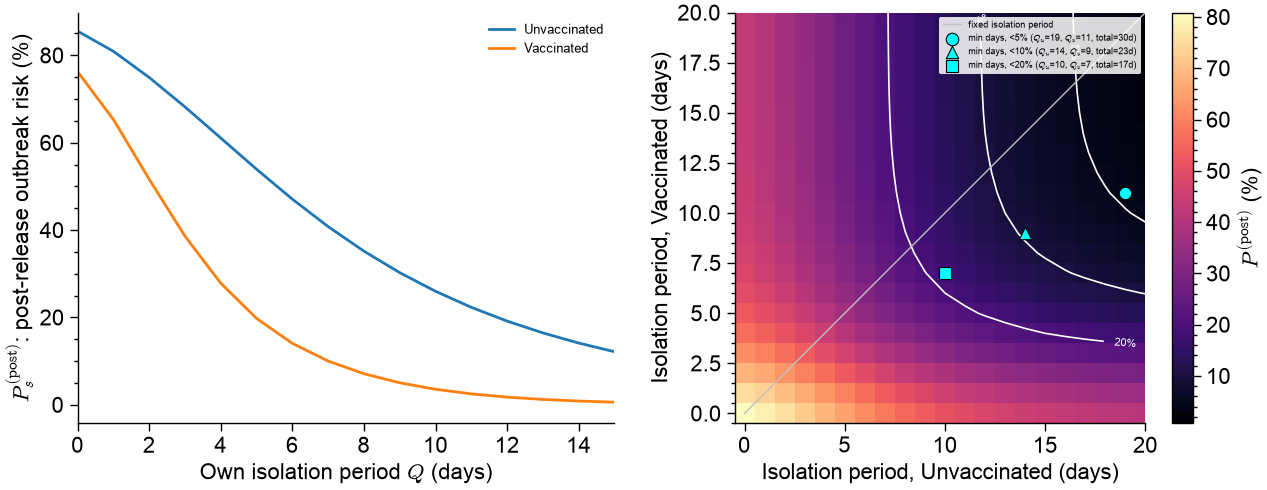

In [24]:
MARKERS_2 = ["o", "^", "s"]

# R_i^(post)(Q) per patient, split by vaccination status -- Eq. 3.4, post-release only
def B_post_per_patient(beta_pop, Q_values):
    out = np.empty((beta_pop.shape[0], len(Q_values)))
    for j, Q in enumerate(Q_values):
        out[:, j] = np.nansum(beta_pop[:, IDX0 + Q:], axis=1)
    return out

R_post_pop = B_post_per_patient(beta_pop, Q_RANGE_FIX)
Rpost_v_i, Rpost_u_i = R_post_pop[vac_mask], R_post_pop[~vac_mask]

P_OUT_AMBIENT = pdf_pmo_1d_sampled(R_v_i[:, :1], R_u_i[:, :1], THETA_VAX_COHORT)[0]
print(f"Ambient p_out (no isolation, theta={THETA_VAX_COHORT}) = {P_OUT_AMBIENT:.4f}")

# Eq. 7.2: average each patient's OWN probability, not the mean rate transformed afterward
P_post_u = np.nanmean(1.0 - np.exp(-Rpost_u_i * P_OUT_AMBIENT), axis=0)
P_post_v = np.nanmean(1.0 - np.exp(-Rpost_v_i * P_OUT_AMBIENT), axis=0)
P_post_grid = (THETA_VAX_COHORT * P_post_v[None, :] + (1 - THETA_VAX_COHORT) * P_post_u[:, None])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(Q_RANGE_FIX, 100 * P_post_u, color=COL_UNVAX, lw=2, label="Unvaccinated")
ax.plot(Q_RANGE_FIX, 100 * P_post_v, color=COL_VAX, lw=2, label="Vaccinated")
ax.set_xlabel("Own isolation period $Q$ (days)")
ax.set_ylabel(r"$P_s^{(\mathrm{post})}$: post-release outbreak risk (%)")
ax.set_xlim(0, 15)
# ax.set_title("4-left. Outbreak risk from post-release transmission, by own release day\n"
#              rf"(ambient risk fixed at {P_OUT_AMBIENT:.3f})", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
levels = [5, 10, 20]
im = ax.imshow(100 * P_post_grid.T, origin="lower",
                extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                        Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                aspect="equal", cmap="magma")
cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * P_post_grid.T, levels=levels, colors="white", linewidths=1.2)
ax.clabel(cs, fmt="%d%%", fontsize=8)
ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, label="fixed isolation period")
for level, marker in zip(levels, MARKERS_2):
    result = combined_min_days(P_post_grid, level / 100.0, Q_RANGE_FIX)
    if result is not None:
        qu, qv, val = result
        ax.scatter(qu, qv, color="cyan", marker=marker, s=80, edgecolors="black", linewidths=0.8,
                   zorder=5, label=rf"min days, <{level}% ($Q_u$={qu}, $Q_v$={qv}, total={qu + qv}d)")
ax.set_xlabel("Isolation period, Unvaccinated (days)")
ax.set_ylabel("Isolation period, Vaccinated (days)")
ax.set_xlim(-0.5, 20)
ax.set_ylim(-0.5, 20)
# ax.set_title(rf"4-right. Population-pooled post-release outbreak risk ($\theta$={THETA_VAX_COHORT})", fontsize=10.5)
fig.colorbar(im, ax=ax, label=r"$P^{(\mathrm{post})}$ (%)")
ax.legend(frameon=True, fontsize=6.5, loc="upper right", framealpha=0.85, edgecolor="none")

# fig.suptitle("Plot 4: outbreak risk attributable to transmission after release, ambient risk held fixed", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.92])
save(fig, "plot4_post_release_outbreak_risk")
plt.show()
plt.close(fig)

## Plot 2: average-optimal vs worst-subgroup-optimal

The existing cyan markers on 2a/2b minimize *total* isolation days subject to the *population-average* risk staying under a threshold (`combined_min_days`, i.e. the PMO_grid/PROB_TRANSMIT_grid value at that point). That can let one subgroup do worse than the threshold as long as the pooled average is still under it -- exactly the Slide 5 finding (average-optimal (7,4) vs. worst-subgroup (8,3) at PMO<10%). Checking whether the same gap shows up on both 2a and 2b, or just 2b.

In [25]:
# per-group 1D curves for 2a (P(>=1 transmission)), reusing the same building blocks
# that PROB_TRANSMIT_grid was assembled from
Pt_v_only = np.nanmean(prob_any_transmission(R_v_i), axis=0)
Pt_u_only = np.nanmean(prob_any_transmission(R_u_i), axis=0)
# PMO_u_only, PMO_v_only already computed above (cell 28) for 2b/Slide 5

levels_2a = [20, 30, 40]
levels_2b = [5, 10, 20]

print(f"{'panel':>6} {'level':>6} {'avg-optimal':>16} {'worst-subgroup':>18} {'differ?':>8}")
for letter, grid, Pt_u, Pt_v, levels in [
    ("2a", PROB_TRANSMIT_grid, Pt_u_only, Pt_v_only, levels_2a),
    ("2b", PMO_grid, PMO_u_only, PMO_v_only, levels_2b),
]:
    for level in levels:
        avg = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        worst = worst_subgroup_min_days(Pt_u, Pt_v, level / 100.0, Q_RANGE_FIX)
        differ = (avg is not None and worst is not None and (avg[0], avg[1]) != worst)
        avg_str = f"({avg[0]},{avg[1]})" if avg else "None"
        worst_str = f"{worst}" if worst else "None"
        print(f"{letter:>6} {level:>5}% {avg_str:>16} {worst_str:>18} {str(differ):>8}")

 panel  level      avg-optimal     worst-subgroup  differ?
    2a    20%           (15,8)            (16, 8)     True
    2a    30%           (10,7)            (12, 6)     True
    2a    40%            (7,6)             (9, 4)     True
    2b     5%            (8,4)             (9, 4)     True
    2b    10%            (7,4)             (8, 3)     True
    2b    20%            (6,4)             (7, 3)     True


## Plot 2 click-to-reveal: worst-subgroup-optimal overlay

All six thresholds differ between average-optimal and worst-subgroup-optimal, on both 2a and 2b (table above) -- not just the PMO panel. Building a transparent overlay (magenta markers, worst-subgroup) pixel-aligned to the existing `plot2_transmission_and_pmo_grids` image (cyan markers, average-optimal), using the same shared-bbox/axes-position capture technique as the Slide 3 pipeline schematic -- paste the overlay directly on top of the base image, no repositioning needed.

Note: 2a's worst-subgroup point at the 20% threshold lands at $(Q_u,Q_v)=(16,8)$, outside the original $x$-axis range (0-15.5) -- both the base and overlay below widen 2a's x-axis to 17 to fit it, so the base image is regenerated (same filename) alongside the new overlay.

saved plot2_transmission_and_pmo_grids


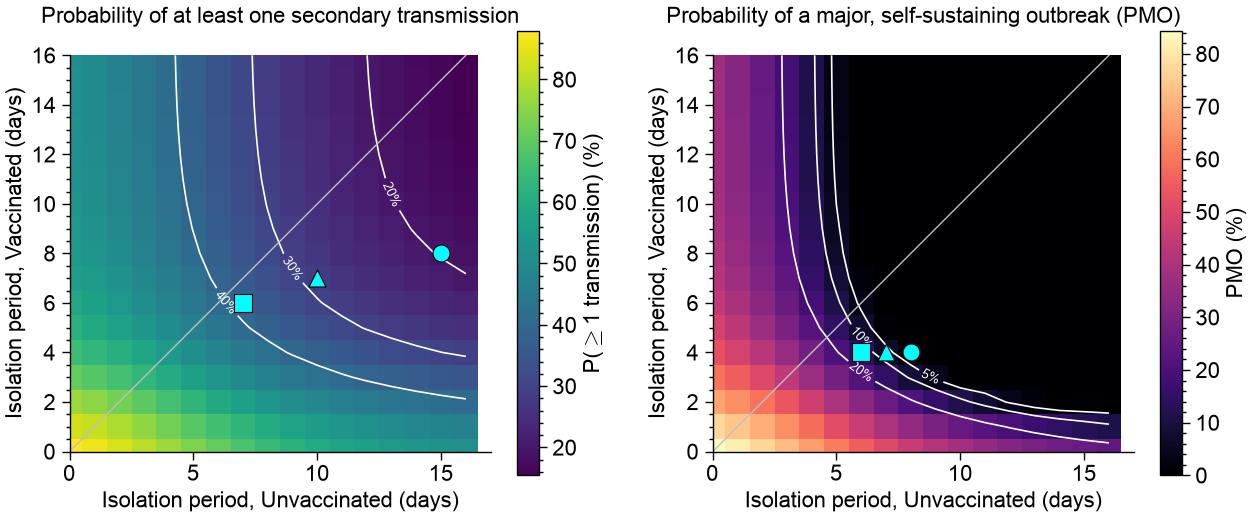

saved plot2_transmission_and_pmo_grids_combined


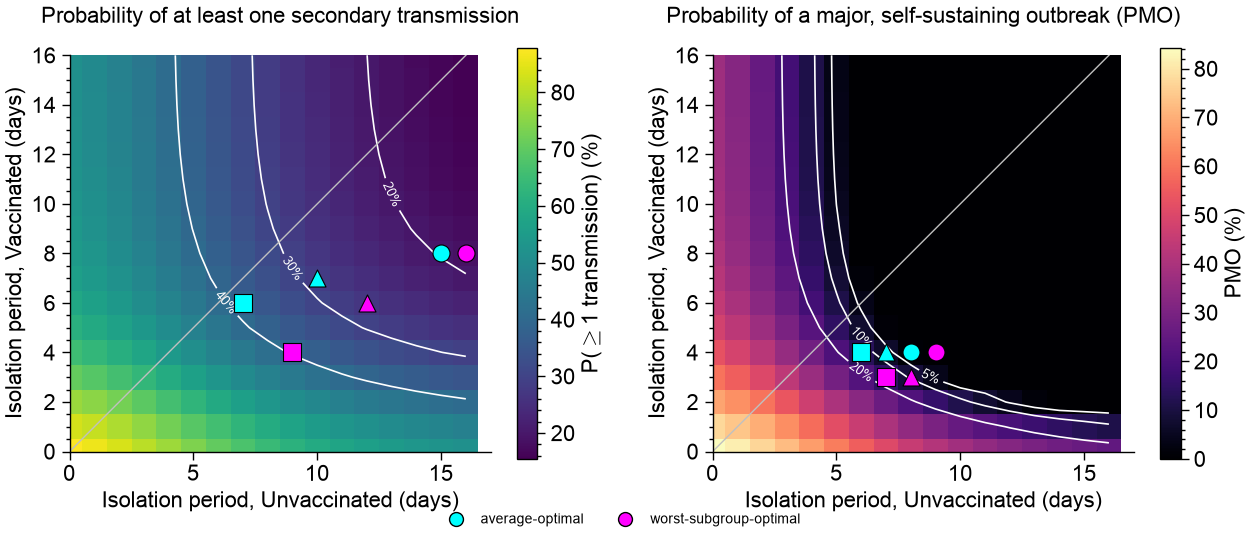

saved plot2_worst_subgroup_overlay


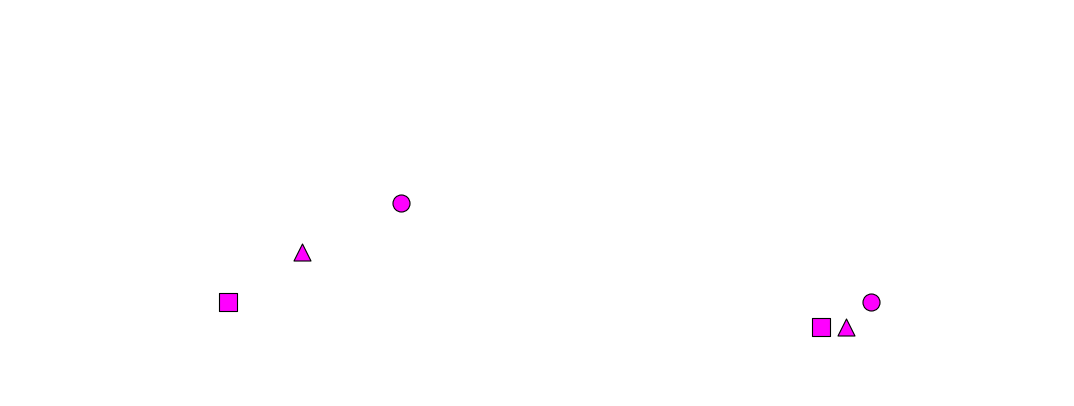

In [26]:
XLIM_2A, XLIM_2B = 17.0, 17.0

def draw_plot2_base(ax, grid, cmap, cbar_label, letter, levels, xlim_max, fig):
    """Heatmap + contour + diagonal + average-optimal (cyan) markers -- matches the
    currently-saved plot2 image exactly."""
    Q_PLOT = Q_RANGE_FIX[Q_RANGE_FIX <= 16]
    grid_plot = grid[:len(Q_PLOT), :len(Q_PLOT)]
    im = ax.imshow(100 * grid_plot.T, origin="lower",
                    extent=[Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5, Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5],
                    aspect="equal", cmap=cmap)
    cs = ax.contour(Q_PLOT, Q_PLOT, 100 * grid_plot.T, levels=levels, colors="white", linewidths=1.2)
    ax.clabel(cs, fmt="%d%%", fontsize=9, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, ls="-")

    for level, marker in zip(levels, MARKERS_2):
        result = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv, val = result
            ax.scatter(qu, qv, color="cyan", marker=marker, s=150, edgecolors="black",
                       linewidths=0.8, zorder=5)

    ax.set_xlabel("Isolation period, Unvaccinated (days)")
    ax.set_ylabel("Isolation period, Vaccinated (days)")
    ax.set_xlim(0, xlim_max)
    ax.set_ylim(0, 16)
    ax.set_title(title_map[letter] + "\n")
    fig.colorbar(im, ax=ax, label=cbar_label)


def draw_plot2_worst(ax, Pt_u, Pt_v, levels, xlim_max):
    """Worst-subgroup-optimal (magenta) markers only -- no heatmap/contour/colorbar."""
    for level, marker in zip(levels, MARKERS_2):
        result = worst_subgroup_min_days(Pt_u, Pt_v, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv = result
            ax.scatter(qu, qv, color="magenta", marker=marker, s=150, edgecolors="black",
                       linewidths=0.8, zorder=6)
    ax.set_xlim(0, xlim_max)
    ax.set_ylim(0, 16)


panels = [
    (PROB_TRANSMIT_grid, "viridis", r"P($\geq$1 transmission) (%)", "2a", [20, 30, 40],
     XLIM_2A, Pt_u_only, Pt_v_only),
    (PMO_grid, "magma", "PMO (%)", "2b", [5, 10, 20], XLIM_2B, PMO_u_only, PMO_v_only),
]
title_map = {"2a": "Probability of at least one secondary transmission",
             "2b": "Probability of a major, self-sustaining outbreak (PMO)"}

# --- full pass: base + worst-subgroup together, purely to capture bbox/axes positions ---
fig = plt.figure(figsize=(13, 5.5))
axes = fig.subplots(1, 2)
for ax, (grid, cmap, cbar_label, letter, levels, xlim_max, Pt_u, Pt_v) in zip(axes, panels):
    draw_plot2_base(ax, grid, cmap, cbar_label, letter, levels, xlim_max, fig)
    draw_plot2_worst(ax, Pt_u, Pt_v, levels, xlim_max)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
shared_bbox = fig.get_tightbbox(renderer).padded(0.15)
axes_pos = [ax.get_position() for ax in axes]
plt.close(fig)

# --- base pass: same content + same tight_layout call as the full pass (NOT a forced
# ax.set_position -- fig.colorbar() creates its own separate axes anchored to ax's
# position at call time, so moving ax afterward strands the colorbar axes behind.
# tight_layout is deterministic given identical content, so it reproduces the full
# pass's positions naturally without needing to touch ax.set_position at all). ---
fig = plt.figure(figsize=(13, 5.5))
axes = fig.subplots(1, 2)
for ax, (grid, cmap, cbar_label, letter, levels, xlim_max, Pt_u, Pt_v) in zip(axes, panels):
    draw_plot2_base(ax, grid, cmap, cbar_label, letter, levels, xlim_max, fig)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(f"{OUT_DIR}/plot2_transmission_and_pmo_grids.svg", bbox_inches=shared_bbox, pad_inches=0.15)
fig.savefig(f"{OUT_DIR}/plot2_transmission_and_pmo_grids.png", dpi=200, bbox_inches=shared_bbox, pad_inches=0.15)
print("saved plot2_transmission_and_pmo_grids")
plt.show()
plt.close(fig)

# --- combined pass: both marker sets baked into one static image (not a click-to-reveal
# pair) -- for backup/appendix use where narrating the reveal isn't needed. ---
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(13, 5.5))
axes = fig.subplots(1, 2)
for ax, (grid, cmap, cbar_label, letter, levels, xlim_max, Pt_u, Pt_v) in zip(axes, panels):
    draw_plot2_base(ax, grid, cmap, cbar_label, letter, levels, xlim_max, fig)
    draw_plot2_worst(ax, Pt_u, Pt_v, levels, xlim_max)
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="cyan", markeredgecolor="black",
           markersize=10, label="average-optimal"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="magenta", markeredgecolor="black",
           markersize=10, label="worst-subgroup-optimal"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.06, 1, 0.92])
save(fig, "plot2_transmission_and_pmo_grids_combined")
plt.show()
plt.close(fig)

# --- overlay pass: transparent, worst-subgroup markers only, pixel-aligned to the base ---
fig = plt.figure(figsize=(13, 5.5))
fig.patch.set_alpha(0)
axes = fig.subplots(1, 2)
for ax, pos, (grid, cmap, cbar_label, letter, levels, xlim_max, Pt_u, Pt_v) in zip(axes, axes_pos, panels):
    draw_plot2_worst(ax, Pt_u, Pt_v, levels, xlim_max)
    ax.set_position(pos)
    ax.axis("off")
    ax.patch.set_alpha(0)
fig.savefig(f"{OUT_DIR}/plot2_worst_subgroup_overlay.svg", bbox_inches=shared_bbox,
            pad_inches=0.15, transparent=True)
fig.savefig(f"{OUT_DIR}/plot2_worst_subgroup_overlay.png", dpi=200, bbox_inches=shared_bbox,
            pad_inches=0.15, transparent=True)
print("saved plot2_worst_subgroup_overlay")
plt.show()
plt.close(fig)

## Plot 4 split into 4a/4b, worst-subgroup layering for 4b

Splitting the combined Plot 4 figure into two separate plots, matching the 2a/2b naming: **4a** is the per-group line plot (post-release outbreak risk vs. own release day), **4b** is the population-pooled grid. Only 4b gets worst-subgroup-optimal markers -- 4a has no optima to mark, it's just the two raw curves 4b's average-optimal search and worst-subgroup search are both built from ($\bar P_u^{(\mathrm{post})}(Q)$, $\bar P_v^{(\mathrm{post})}(Q)$).

Same construction as 2b's worst-subgroup: `worst_subgroup_min_days(P_post_u, P_post_v, thresh, Q_RANGE_FIX)` finds each group's own minimum $Q$ against its own curve, independently -- no joint search, same caveat about pooled-average masking one group applies here too.

saved plot4a_post_release_by_group


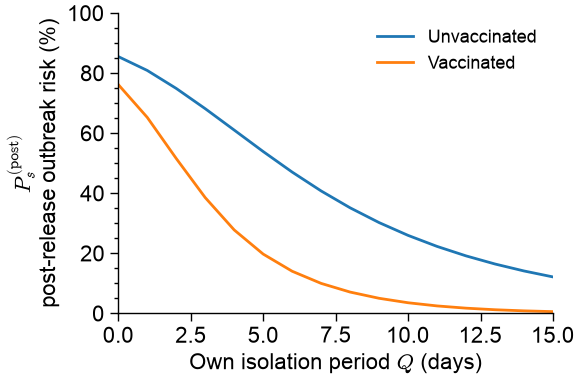

In [27]:
# --- 4a: per-group post-release outbreak risk, standalone ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Q_RANGE_FIX, 100 * P_post_u, color=COL_UNVAX, lw=2, label="Unvaccinated")
ax.plot(Q_RANGE_FIX, 100 * P_post_v, color=COL_VAX, lw=2, label="Vaccinated")
ax.set_xlabel("Own isolation period $Q$ (days)")
ax.set_ylabel(r"$P_s^{(\mathrm{post})}$""\npost-release outbreak risk (%)")
ax.set_xlim(0, 15)
ax.set_ylim(0,100)
ax.legend(frameon=False, fontsize=13)
fig.tight_layout()
save(fig, "plot4a_post_release_by_group")
plt.show()
plt.close(fig)

 level      avg-optimal     worst-subgroup
    5%          (19,11)           (21, 10)
   10%           (14,9)            (17, 7)
   20%           (10,7)            (12, 5)


saved plot4b_post_release_pooled_grid


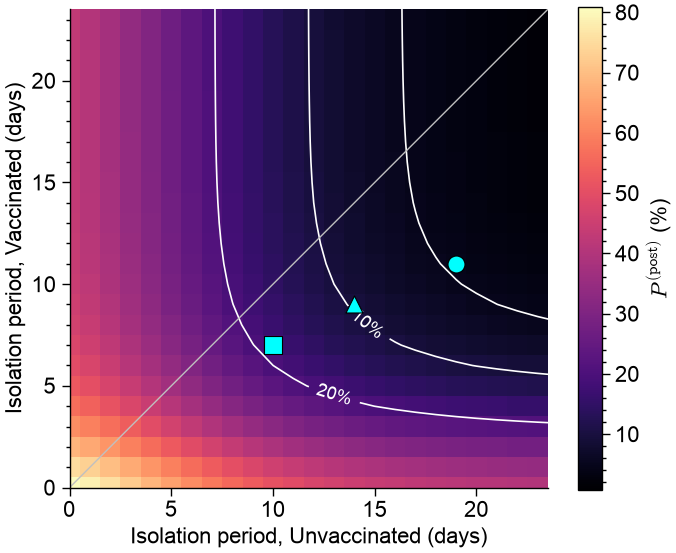

saved plot4b_worst_subgroup_overlay


saved plot4b_pooled_grid_combined


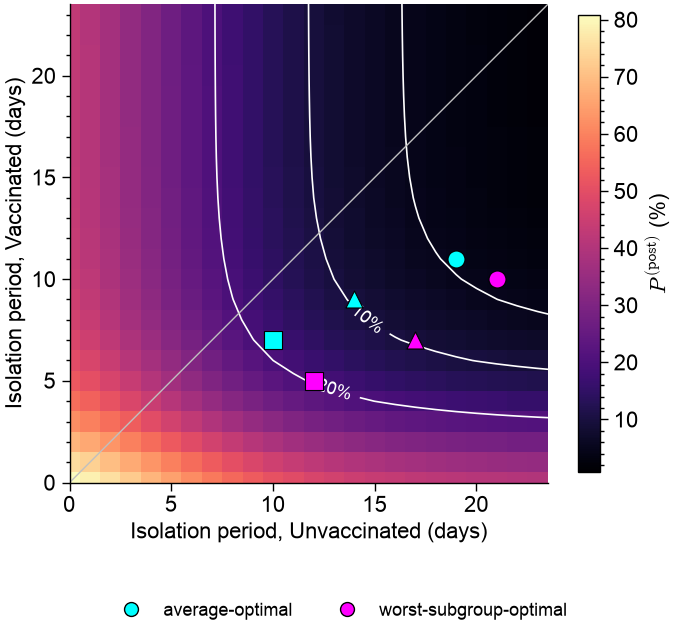

In [28]:
# --- 4b: population-pooled grid, with average-optimal + worst-subgroup-optimal ---
levels_4b = [5, 10, 20]
XLIM_4B = 23.5

print(f"{'level':>6} {'avg-optimal':>16} {'worst-subgroup':>18}")
for level in levels_4b:
    avg = combined_min_days(P_post_grid, level / 100.0, Q_RANGE_FIX)
    worst = worst_subgroup_min_days(P_post_u, P_post_v, level / 100.0, Q_RANGE_FIX)
    avg_str = f"({avg[0]},{avg[1]})" if avg else "None"
    print(f"{level:>5}% {avg_str:>16} {str(worst):>18}")


def draw_4b_base(ax, fig):
    im = ax.imshow(100 * P_post_grid.T, origin="lower",
                    extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                            Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                    aspect="equal", cmap="magma")
    cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * P_post_grid.T, levels=levels_4b,
                     colors="white", linewidths=1.2)
    ax.clabel(cs, fmt="%d%%", fontsize=13, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0)

    for level, marker in zip(levels_4b, MARKERS_2):
        result = combined_min_days(P_post_grid, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv, val = result
            ax.scatter(qu, qv, color="cyan", marker=marker, s=150, edgecolors="black",
                       linewidths=0.8, zorder=5)

    ax.set_xlabel("Isolation period, Unvaccinated (days)")
    ax.set_ylabel("Isolation period, Vaccinated (days)")
    ax.set_xlim(0, XLIM_4B)
    ax.set_ylim(0, XLIM_4B)
    fig.colorbar(im, ax=ax, label=r"$P^{(\mathrm{post})}$ (%)",shrink=0.7)


def draw_4b_worst(ax):
    for level, marker in zip(levels_4b, MARKERS_2):
        result = worst_subgroup_min_days(P_post_u, P_post_v, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv = result
            ax.scatter(qu, qv, color="magenta", marker=marker, s=150, edgecolors="black",
                       linewidths=0.8, zorder=6)
    ax.set_xlim(0, XLIM_4B)
    ax.set_ylim(0, XLIM_4B)


# full pass -- capture bbox/axes position only
fig = plt.figure(figsize=(7, 7.2))
ax = fig.add_subplot(111)
draw_4b_base(ax, fig)
draw_4b_worst(ax)
fig.tight_layout()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
shared_bbox_4b = fig.get_tightbbox(renderer).padded(0.15)
pos_4b = ax.get_position()
plt.close(fig)

# base pass -- same content + same tight_layout call, matches 2b's approach exactly
fig = plt.figure(figsize=(7, 7.2))
ax = fig.add_subplot(111)
draw_4b_base(ax, fig)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/plot4b_post_release_pooled_grid.svg", bbox_inches=shared_bbox_4b, pad_inches=0.15)
fig.savefig(f"{OUT_DIR}/plot4b_post_release_pooled_grid.png", dpi=200, bbox_inches=shared_bbox_4b, pad_inches=0.15)
print("saved plot4b_post_release_pooled_grid")
plt.show()
plt.close(fig)

# overlay pass -- transparent, worst-subgroup markers only, pixel-aligned to base
fig = plt.figure(figsize=(7, 7.2))
fig.patch.set_alpha(0)
ax = fig.add_subplot(111)
draw_4b_worst(ax)
ax.set_position(pos_4b)
ax.axis("off")
ax.patch.set_alpha(0)
fig.savefig(f"{OUT_DIR}/plot4b_worst_subgroup_overlay.svg", bbox_inches=shared_bbox_4b,
            pad_inches=0.15, transparent=True)
fig.savefig(f"{OUT_DIR}/plot4b_worst_subgroup_overlay.png", dpi=200, bbox_inches=shared_bbox_4b,
            pad_inches=0.15, transparent=True)
print("saved plot4b_worst_subgroup_overlay")
plt.close(fig)

# combined pass -- both marker sets baked in, with legend
fig = plt.figure(figsize=(7, 7.2))
ax = fig.add_subplot(111)
draw_4b_base(ax, fig)
draw_4b_worst(ax)
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="cyan", markeredgecolor="black",
           markersize=10, label="average-optimal"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="magenta", markeredgecolor="black",
           markersize=10, label="worst-subgroup-optimal"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False,
           fontsize=13, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.05, 1, 1])
save(fig, "plot4b_pooled_grid_combined")
plt.show()
plt.close(fig)

## New slide: non-isolation sweep (reframed asymptomatic extension)

Reframing the asymptomatic extension more generally as *the portion who do not isolate, for any reason* -- imperfect compliance among symptomatic/detected people, not just non-detection of asymptomatic ones (and some asymptomatic people do isolate too, e.g. via contact tracing). This drops the asymptomatic-specific infectiousness discount $\rho$ entirely -- someone who doesn't isolate uses their own ordinary $R_i$, no claim needed about *why* they didn't isolate or whether they're systematically more or less infectious.

Mechanically this reuses the existing `pdf_pmo_2d_sampled_asymp` unchanged, just with $x_v=x_u=0$ (asymptomatic branch switched off) and $\phi$ swept -- reducing its 3-branch mixture to the plain isolate/don't-isolate split:
$$q(Q_u,Q_v) = \theta\Big[\phi\,\mathrm{mean}_i\big(e^{-R_{v,i}(Q_v)(1-q)}\big) + (1-\phi)\,\mathrm{mean}_i\big(e^{-R_{v,i}(0)(1-q)}\big)\Big] + (1-\theta)\Big[\phi\,\mathrm{mean}_i\big(e^{-R_{u,i}(Q_u)(1-q)}\big) + (1-\phi)\,\mathrm{mean}_i\big(e^{-R_{u,i}(0)(1-q)}\big)\Big]$$
$$\mathrm{PMO}(Q_u,Q_v;\phi) = 1-q(Q_u,Q_v;\phi)$$

$\phi=1$ (everyone isolates) reproduces the ordinary PMO_grid (2b) exactly -- checked below. Sweeping $\phi$ down shows how much of the isolation policy's protection a given non-isolating fraction erodes.

phi=1 matches PMO_grid, max abs diff: 0.0


saved phi_noniso_sweep_pmo_heatmaps


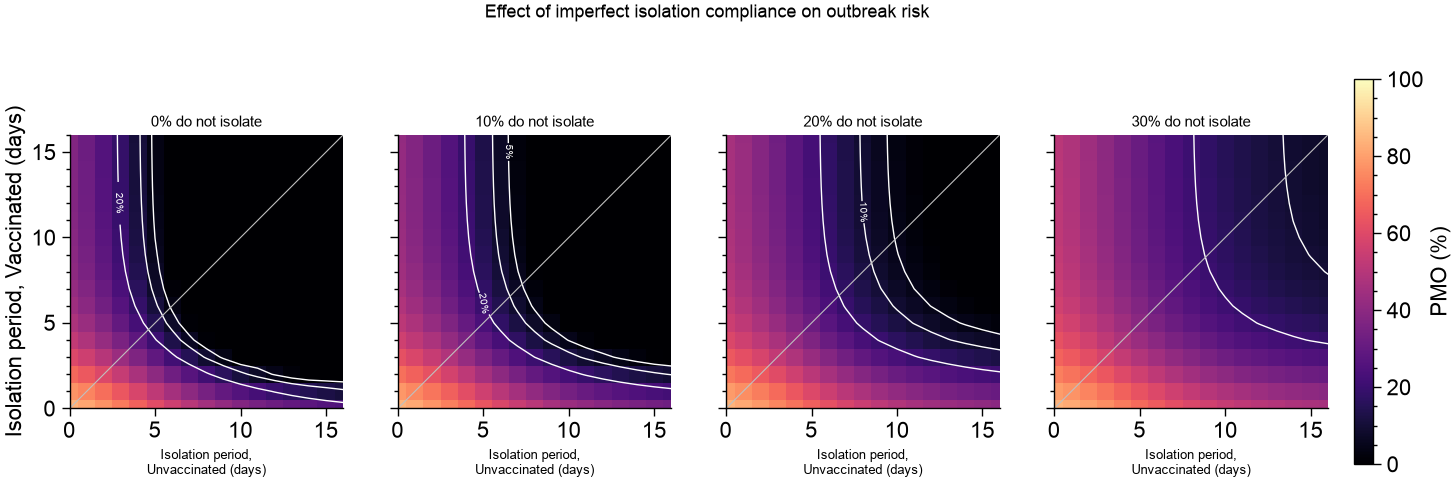

In [29]:
NONISO_FRACS = [0.0, 0.10, 0.20, 0.30]   # 1 - phi
PHI_VALUES = [1.0 - f for f in NONISO_FRACS]

# sanity check: phi=1 must reproduce the ordinary PMO_grid exactly (x=0 disables the
# asymptomatic branch, phi=1 disables the non-isolating branch -- nothing left but the
# plain isolating case, i.e. pdf_pmo_2d_sampled)
_check = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=0.0, x_u=0.0, rho=1.0, phi=1.0)
print("phi=1 matches PMO_grid, max abs diff:", np.max(np.abs(_check - PMO_grid)))

grids_phi = [pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=0.0, x_u=0.0, rho=1.0, phi=phi)
             for phi in PHI_VALUES]

fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
levels_sweep = [5, 10, 20]
for ax, frac, grid in zip(axes, NONISO_FRACS, grids_phi):
    im = ax.imshow(100 * grid.T, origin="lower",
                    extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                            Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                    aspect="equal", cmap="magma", vmin=0, vmax=100)
    cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * grid.T, levels=levels_sweep,
                     colors="white", linewidths=1.0)
    ax.clabel(cs, fmt="%d%%", fontsize=7, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=0.8)
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)
    ax.set_xlabel("Isolation period,\nUnvaccinated (days)", fontsize=9.5)
    ax.set_title(f"{int(100*frac)}% do not isolate", fontsize=11)
axes[0].set_ylabel("Isolation period, Vaccinated (days)")
fig.colorbar(im, ax=axes, label="PMO (%)", fraction=0.025, pad=0.02)
fig.suptitle("Effect of imperfect isolation compliance on outbreak risk", fontsize=13, y=1.03)
save(fig, "phi_noniso_sweep_pmo_heatmaps")
plt.show()
plt.close(fig)

In [30]:
# Diagnostic: is the 30% non-compliance panel's high PMO actually consistent with the
# R_eff mechanism, or is something off? Check the R_eff FLOOR (as Q->max) directly.
phi_check = 0.7  # 30% non-compliance

Rv_bar0 = np.nanmean(R_v_i[:, 0])   # mean R at Q=0 (full, unconstrained)
Ru_bar0 = np.nanmean(R_u_i[:, 0])
Rv_floor = np.nanmean(R_v_i[:, -1])  # mean R at Q=Q_RANGE_FIX[-1]=30 (longest isolation)
Ru_floor = np.nanmean(R_u_i[:, -1])
print(f"R_v: Q=0 mean={Rv_bar0:.4f}  Q=30 floor={Rv_floor:.4f}")
print(f"R_u: Q=0 mean={Ru_bar0:.4f}  Q=30 floor={Ru_floor:.4f}")

# R_eff floor as Qu,Qv -> max grid point (30), under phi-mixing:
# R_eff = theta*[phi*Rv_floor + (1-phi)*Rv_bar0] + (1-theta)*[phi*Ru_floor + (1-phi)*Ru_bar0]
Reff_floor = (THETA_VAX_COHORT * (phi_check * Rv_floor + (1 - phi_check) * Rv_bar0)
              + (1 - THETA_VAX_COHORT) * (phi_check * Ru_floor + (1 - phi_check) * Ru_bar0))
print(f"\nR_eff floor at phi={phi_check} (Qu=Qv=30, max grid): {Reff_floor:.4f}")

# actual PMO at the grid's max Q (30,30) and at the plotted-panel's max (16,16)
grid_30pct = grids_phi[NONISO_FRACS.index(0.30)]
qi16 = list(Q_RANGE_FIX).index(16)
qi30 = list(Q_RANGE_FIX).index(30)
print(f"\nPMO(Qu=16,Qv=16; phi={phi_check}) = {100*grid_30pct[qi16, qi16]:.2f}%")
print(f"PMO(Qu=30,Qv=30; phi={phi_check}) = {100*grid_30pct[qi30, qi30]:.2f}%")

# and for comparison, what PMO would a homogeneous population with R=Reff_floor give,
# via the textbook single-type formula PMO = 1 - 1/R_eff (for R_eff>1)?
if Reff_floor > 1:
    print(f"textbook max{{1-1/R_eff,0}} at this R_eff: {100*max(1-1/Reff_floor,0):.2f}%")

R_v: Q=0 mean=2.3879  Q=30 floor=0.2103
R_u: Q=0 mean=3.9132  Q=30 floor=0.1614

R_eff floor at phi=0.7 (Qu=Qv=30, max grid): 1.0753

PMO(Qu=16,Qv=16; phi=0.7) = 7.53%
PMO(Qu=30,Qv=30; phi=0.7) = 3.44%
textbook max{1-1/R_eff,0} at this R_eff: 7.00%


In [31]:
# Diagnostic pass before building the overlay: per-panel average-optimal vs
# worst-subgroup-optimal, and check none land outside a sane axis range.
levels_sweep = [5, 10, 20]

PMO_u_only_phi = {}
PMO_v_only_phi = {}
for phi in PHI_VALUES:
    PMO_u_only_phi[phi] = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, 0.0, 0.0, 0.0, 1.0, phi=phi)
    PMO_v_only_phi[phi] = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, 1.0, 0.0, 0.0, 1.0, phi=phi)

print(f"{'noniso%':>8} {'level':>6} {'avg-optimal':>16} {'worst-subgroup':>18}")
for frac, phi, grid in zip(NONISO_FRACS, PHI_VALUES, grids_phi):
    for level in levels_sweep:
        avg = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        worst = worst_subgroup_min_days(PMO_u_only_phi[phi], PMO_v_only_phi[phi], level / 100.0, Q_RANGE_FIX)
        avg_str = f"({avg[0]},{avg[1]})" if avg else "None"
        print(f"{int(100*frac):>7}% {level:>5}% {avg_str:>16} {str(worst):>18}")

 noniso%  level      avg-optimal     worst-subgroup
      0%     5%            (8,4)             (9, 4)
      0%    10%            (7,4)             (8, 3)
      0%    20%            (6,4)             (7, 3)
     10%     5%            (9,5)            (11, 4)
     10%    10%            (8,5)            (10, 4)
     10%    20%            (7,4)             (9, 3)
     20%     5%           (12,6)            (16, 5)
     20%    10%           (10,6)            (14, 5)
     20%    20%            (8,5)            (11, 4)
     30%     5%          (23,12)          (None, 6)
     30%    10%           (16,8)          (None, 6)
     30%    20%           (11,6)            (15, 5)


## Non-isolation sweep: average-optimal vs worst-subgroup-optimal overlay

Same cyan/magenta treatment as 2b and 4b, now across all four non-compliance panels. Note the 30% panel: worst-subgroup is **infeasible** for the 5% and 10% thresholds -- `worst_subgroup_min_days` returns `None` for $Q_u$, because unvaccinated-only PMO never drops below those thresholds no matter how long they isolate (their own $\mathcal R_{\mathrm{eff}}$ floor under 30% non-compliance stays above both). Those markers are simply omitted rather than plotted at some arbitrary point -- a real result, not a missing-data gap. Separately, the 30% panel's **average-optimal** markers for the 5% and 10% thresholds land at Qu=23 and Qu=16 -- outside the shared 0-16 day axis used across all four panels (kept shared deliberately, for direct visual comparison across compliance levels). Those two points are noted in-panel rather than plotted off-chart.

saved phi_noniso_sweep_pmo_heatmaps


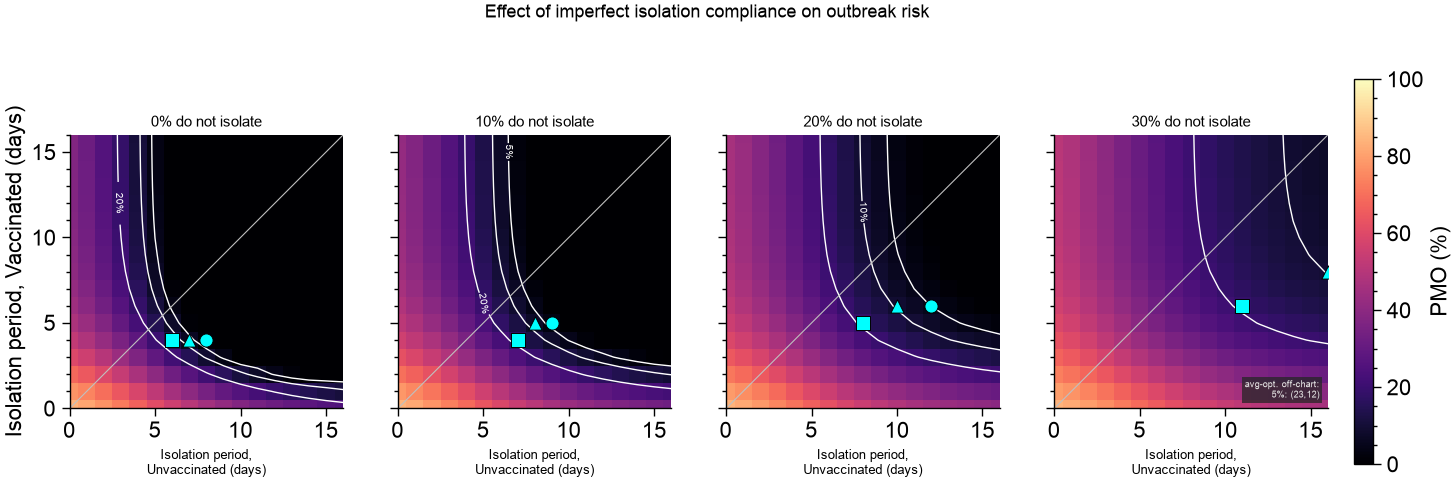

saved phi_noniso_sweep_worst_subgroup_overlay


saved phi_noniso_sweep_combined


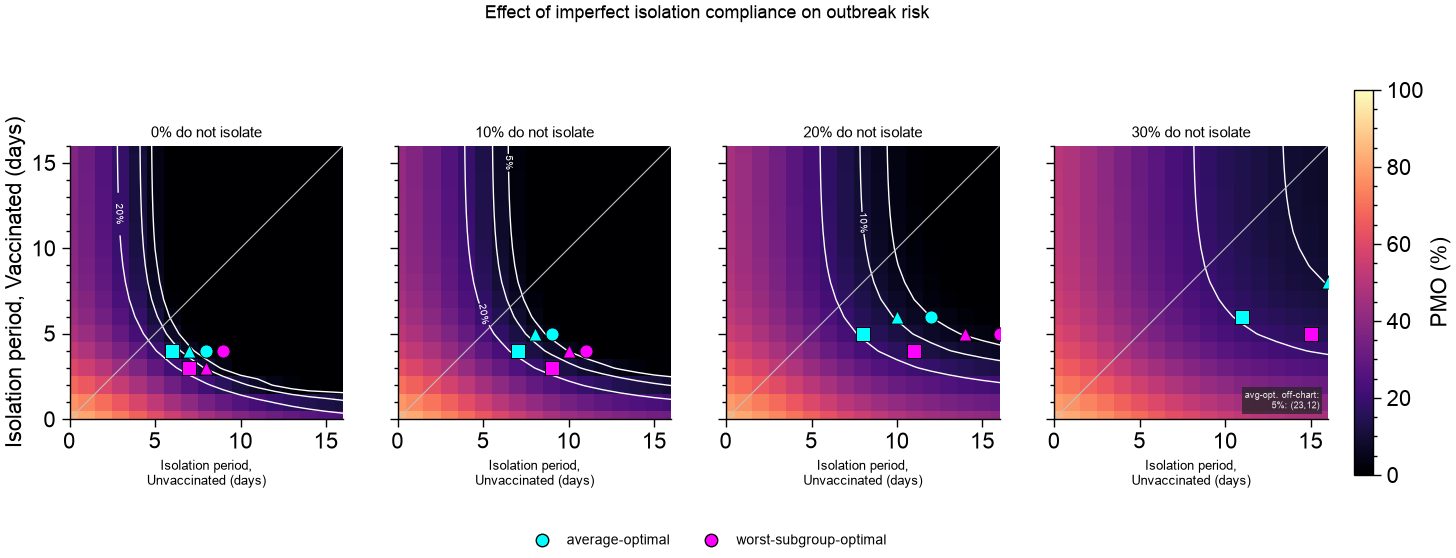

In [32]:
def draw_sweep_base(ax, grid, frac, fig=None, im_list=None):
    im = ax.imshow(100 * grid.T, origin="lower",
                    extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                            Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                    aspect="equal", cmap="magma", vmin=0, vmax=100)
    cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * grid.T, levels=levels_sweep,
                     colors="white", linewidths=1.0)
    ax.clabel(cs, fmt="%d%%", fontsize=7, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=0.8)

    AX_MAX = 16
    off_chart = []
    for level, marker in zip(levels_sweep, MARKERS_2):
        result = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv, val = result
            if qu <= AX_MAX and qv <= AX_MAX:
                ax.scatter(qu, qv, color="cyan", marker=marker, s=90, edgecolors="black",
                           linewidths=0.7, zorder=5)
            else:
                off_chart.append(f"{level}%: ({qu},{qv})")

    ax.set_xlim(0, AX_MAX)
    ax.set_ylim(0, AX_MAX)
    ax.set_xlabel("Isolation period,\nUnvaccinated (days)", fontsize=9.5)
    ax.set_title(f"{int(100*frac)}% do not isolate", fontsize=11)
    if off_chart:
        ax.text(0.97, 0.03, "avg-opt. off-chart:\n" + "\n".join(off_chart),
                transform=ax.transAxes, fontsize=6.5, color="0.9", ha="right", va="bottom",
                bbox=dict(fc="0.15", ec="none", alpha=0.75, pad=2))
    if im_list is not None:
        im_list.append(im)
    return im


def draw_sweep_worst(ax, phi):
    for level, marker in zip(levels_sweep, MARKERS_2):
        result = worst_subgroup_min_days(PMO_u_only_phi[phi], PMO_v_only_phi[phi], level / 100.0, Q_RANGE_FIX)
        qu, qv = result
        if qu is not None and qv is not None:
            ax.scatter(qu, qv, color="magenta", marker=marker, s=90, edgecolors="black",
                       linewidths=0.7, zorder=6)
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)


# --- full pass: base + worst-subgroup together, purely to capture bbox/axes positions ---
fig = plt.figure(figsize=(17, 5))
axes = fig.subplots(1, 4, sharey=True)
im_list = []
for ax, frac, phi, grid in zip(axes, NONISO_FRACS, PHI_VALUES, grids_phi):
    draw_sweep_base(ax, grid, frac, im_list=im_list)
    draw_sweep_worst(ax, phi)
axes[0].set_ylabel("Isolation period, Vaccinated (days)")
fig.colorbar(im_list[-1], ax=axes, label="PMO (%)", fraction=0.025, pad=0.02)
fig.suptitle("Effect of imperfect isolation compliance on outbreak risk", fontsize=13, y=1.03)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
shared_bbox_sweep = fig.get_tightbbox(renderer).padded(0.15)
axes_pos_sweep = [ax.get_position() for ax in axes]
plt.close(fig)

# --- base pass: same content + same layout calls as full pass (tight_layout is
# deterministic given identical content, so it reproduces the full pass's positions
# naturally -- same reasoning as 2b/4b, avoids stranding the shared colorbar axes) ---
fig = plt.figure(figsize=(17, 5))
axes = fig.subplots(1, 4, sharey=True)
im_list = []
for ax, frac, grid in zip(axes, NONISO_FRACS, grids_phi):
    draw_sweep_base(ax, grid, frac, im_list=im_list)
axes[0].set_ylabel("Isolation period, Vaccinated (days)")
fig.colorbar(im_list[-1], ax=axes, label="PMO (%)", fraction=0.025, pad=0.02)
fig.suptitle("Effect of imperfect isolation compliance on outbreak risk", fontsize=13, y=1.03)
fig.savefig(f"{OUT_DIR}/phi_noniso_sweep_pmo_heatmaps.svg", bbox_inches=shared_bbox_sweep, pad_inches=0.15)
fig.savefig(f"{OUT_DIR}/phi_noniso_sweep_pmo_heatmaps.png", dpi=200, bbox_inches=shared_bbox_sweep, pad_inches=0.15)
print("saved phi_noniso_sweep_pmo_heatmaps")
plt.show()
plt.close(fig)

# --- overlay pass: transparent, worst-subgroup markers only, pixel-aligned to base ---
fig = plt.figure(figsize=(17, 5))
fig.patch.set_alpha(0)
axes = fig.subplots(1, 4, sharey=True)
for ax, pos, phi in zip(axes, axes_pos_sweep, PHI_VALUES):
    draw_sweep_worst(ax, phi)
    ax.set_position(pos)
    ax.axis("off")
    ax.patch.set_alpha(0)
fig.savefig(f"{OUT_DIR}/phi_noniso_sweep_worst_subgroup_overlay.svg", bbox_inches=shared_bbox_sweep,
            pad_inches=0.15, transparent=True)
fig.savefig(f"{OUT_DIR}/phi_noniso_sweep_worst_subgroup_overlay.png", dpi=200, bbox_inches=shared_bbox_sweep,
            pad_inches=0.15, transparent=True)
print("saved phi_noniso_sweep_worst_subgroup_overlay")
plt.close(fig)

# --- combined pass: both marker sets baked in, with legend ---
fig = plt.figure(figsize=(17, 5))
axes = fig.subplots(1, 4, sharey=True)
im_list = []
for ax, frac, phi, grid in zip(axes, NONISO_FRACS, PHI_VALUES, grids_phi):
    draw_sweep_base(ax, grid, frac, im_list=im_list)
    draw_sweep_worst(ax, phi)
axes[0].set_ylabel("Isolation period, Vaccinated (days)")
fig.colorbar(im_list[-1], ax=axes, label="PMO (%)", fraction=0.025, pad=0.02)
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="cyan", markeredgecolor="black",
           markersize=9, label="average-optimal"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="magenta", markeredgecolor="black",
           markersize=9, label="worst-subgroup-optimal"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Effect of imperfect isolation compliance on outbreak risk", fontsize=13, y=1.05)
save(fig, "phi_noniso_sweep_combined")
plt.show()
plt.close(fig)

In [33]:
# What is this project's ACTUAL dispersion (not the proxy sigma=0.6 guess)?
R0_pooled = np.concatenate([R_v_i[:, 0], R_u_i[:, 0]])   # every patient's own R at Q=0
mean_R, sd_R = R0_pooled.mean(), R0_pooled.std()
cv_R = sd_R / mean_R
k_equiv = 1 / cv_R**2
print(f"pooled R(Q=0): mean={mean_R:.3f}  sd={sd_R:.3f}  CV={cv_R:.3f}  k_equivalent={k_equiv:.3f}")

for name, arr in [("vaccinated", R_v_i[:, 0]), ("unvaccinated", R_u_i[:, 0])]:
    cv = arr.std() / arr.mean()
    print(f"{name}: mean={arr.mean():.3f}  sd={arr.std():.3f}  CV={cv:.3f}  k_equivalent={1/cv**2:.3f}")

# Proof of concept: add an independent contact-rate/activity factor c_i ~ Gamma(k, 1/k)
# (mean 1) on top of the existing viral-kinetics heterogeneity -- Note Section 9's own
# suggested extension ("Heterogeneous contact rates... multiplying each class-specific
# infectiousness profile by a contact-rate factor"). Check what k is needed to reach
# literature-typical superspreading levels.
rng_k = np.random.default_rng(3)
print(f"\n{'target k':>9} {'p_out (ambient, ~R0=3)':>24}")
for k_target in [np.inf, 2.0, 1.0, 0.5, 0.3, 0.1]:
    if np.isinf(k_target):
        Rv_k, Ru_k = R_v_i[:, :1], R_u_i[:, :1]
    else:
        c_v = rng_k.gamma(shape=k_target, scale=1.0 / k_target, size=(R_v_i.shape[0], 1))
        c_u = rng_k.gamma(shape=k_target, scale=1.0 / k_target, size=(R_u_i.shape[0], 1))
        Rv_k, Ru_k = R_v_i[:, :1] * c_v, R_u_i[:, :1] * c_u
    p_amb = pdf_pmo_1d_sampled(Rv_k, Ru_k, THETA_VAX_COHORT)[0]
    print(f"{k_target!s:>9} {100*p_amb:>23.2f}%")

pooled R(Q=0): mean=3.152  sd=2.256  CV=0.716  k_equivalent=1.951
vaccinated: mean=2.388  sd=1.284  CV=0.538  k_equivalent=3.461
unvaccinated: mean=3.913  sd=2.713  CV=0.693  k_equivalent=2.080

 target k   p_out (ambient, ~R0=3)
      inf                   84.25%
      2.0                   73.33%
      1.0                   58.68%
      0.5                   43.39%
      0.3                   33.61%
      0.1                   13.49%
